In [72]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import joblib
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import ipywidgets as widgets


In [73]:
# [Cell 1: LOAD DATA + FEATURE ENGINEERING]

INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)

def enrich_features_v2(df):
    """
    Final Strategic Consolidation:
    - Ranked Deduplication (Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - Full Integrity Audit Printing.
    """

    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)

    # --- STEP 1: RANKED DEDUPLICATION ---
    df = df.sort_values(
        ['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'],
        ascending=[True, True, True, False, False]
    )
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)

    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # --- STEP 3: INTEGRITY AUDIT ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]

    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")

    # --- STEP 4: CORE FEATURES ---
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)

    df['Season_Phase'] = pd.cut(
        df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]
    ).astype(float)

    # --- STEP 5: TEAM POINT SHARE (fully lagged, no leakage) ---
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        df['_prev_individual_pts'] = df.groupby('Player UUID')['Total Points'].shift(1)
        df['_prev_team_total'] = df.groupby(
            [team_col, 'season', 'Gameweek']
        )['_prev_individual_pts'].transform('sum')

        df['Team_Point_Share'] = (
            df['_prev_individual_pts'] / df['_prev_team_total']
        ).replace([np.inf, -np.inf], 0).fillna(0)

        df.drop(columns=['_prev_individual_pts', '_prev_team_total'], inplace=True)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 6: SEASON BASELINE BRIDGE (no current-season leakage) ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)

    # shift(1) on the season axis: season N gets season N-1's completed average
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby(
        'Player UUID'
    )['Season_Avg_Points'].shift(1)

    df = df.merge(
        season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']],
        on=['Player UUID', 'season'],
        how='left'
    )
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    # --- FINAL STEP: DROP ROWS WHERE NEXT MATCH CONTEXT IS UNKNOWN ---
    return df.dropna(subset=['Next_Opponent_Difficulty'])


# Run and Save
df_augmented = enrich_features_v2(df)
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')

print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")
display(df_augmented[[
    'Player Name', 'season', 'Gameweek',
    'Prev_Season_Avg_Points', 'Rolling_Avg_Minutes_5'
]].head())

--- Final Integrity Audit ---
Legitimate DGW Match Pairs (Time-Series): 2465
Suspicious GWs (>2 matches): 0 (TARGET: 0)
Max Minutes in a single row: 90
Enhanced dataset created: ../output/forecaster_pro/fpl_features_augmented.csv


,Player Name,season,Gameweek,Prev_Season_Avg_Points,Rolling_Avg_Minutes_5
1,Alex Nicolao Telles,2020-21,9,0.0,0.000000
2,Alex Nicolao Telles,2020-21,10,0.0,90.000000
3,Alex Nicolao Telles,2020-21,11,0.0,86.500000
4,Alex Nicolao Telles,2020-21,13,0.0,87.666667
5,Alex Nicolao Telles,2020-21,14,0.0,88.250000


In [74]:
#  [Cell: Final Data Scrub - Removing Verified Ghosts]

# List of players verified as inactive in the 2025-26 Premier League
verified_ghosts = ['Thiago', 'Mane', 'Bale', 'Sadio Mané']

# Filter out these specific names ONLY for the 2025-26 season rows
# We keep them for older seasons so the model can still learn from their history
initial_count = len(df_augmented)

df_augmented = df_augmented[~(
    (df_augmented['Web Name'].isin(verified_ghosts)) & 
    (df_augmented['season'] == '2025-26')
)].copy()

removed_count = initial_count - len(df_augmented)
print(f"Surgical Clean Complete: Removed {removed_count} ghost rows from 2025-26.")

Surgical Clean Complete: Removed 27 ghost rows from 2025-26.


## Prev_Season_Avg_Points

It calculates the average points a player earned over the entire previous season.

It maps that average forward to the current season.

Result: The model now knows if a player is "Class" (e.g., Salah averaging 7 points all year) vs. just being in "Form" for a few weeks. This makes GW1 and GW2 predictions much more stable.

In [75]:
# [Cell: Verification - Salah's Season Bridge]

# 1. Identify Salah's UUID
# (search for 'salah' in the Web Name to be safe)
salah_data = df_augmented[df_augmented['Web Name'].str.contains('Salah', case=False, na=False)]

if not salah_data.empty:
    s_uuid = salah_data['Player UUID'].iloc[0]
    
    # 2. Get the transition rows (End of 24/25 and Start of 25/26)
    # We sort to ensure chronological order
    salah_history = df_augmented[df_augmented['Player UUID'] == s_uuid].sort_values(['season', 'Gameweek'])
    
    # 3. Find the exact point where 2024-25 ends and 2025-26 begins
    transition_mask = (salah_history['season'] == '2025-26') & (salah_history['season'].shift(1) == '2024-25')
    
    if transition_mask.any():
        idx = salah_history[transition_mask].index[0]
        # Get 3 games before and 3 games after the summer break
        display_df = salah_history.loc[idx-3 : idx+2]
        
        print(f"--- Verification: Season Baseline Bridge (Mohamed Salah) ---")
        print("Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.")
        display(display_df[['Player Name', 'season', 'Gameweek', 'Total Points', 'Prev_Season_Avg_Points']])
    else:
        print("Could not find the 2024-25 to 2025-26 transition for Salah in this specific slice.")
else:
    print("Salah not found in the current df_augmented slice.")

--- Verification: Season Baseline Bridge (Mohamed Salah) ---
Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.


,Player Name,season,Gameweek,Total Points,Prev_Season_Avg_Points
2096,Mohamed Salah,2024-25,36,2,6.593750
2097,Mohamed Salah,2024-25,37,2,6.593750
2099,Mohamed Salah,2025-26,1,8,9.052632
2100,Mohamed Salah,2025-26,2,5,9.052632
2101,Mohamed Salah,2025-26,3,3,9.052632


In [76]:
#INVESTIGATION IN THE INPUT FILE 

# 1. Look at the suspicious GWs
dgws_investigation = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

print(f"Investigating {len(dgws_investigation)} rows from suspicious Gameweeks...")

# 2. Check the 180 minute rows specifically
high_min_rows = df[df['Minutes Played'] >= 180]

print(f"Found {len(high_min_rows)} rows in the RAW dataset with >= 180 minutes.")

if not high_min_rows.empty:
    print("\nSample of 180-minute rows (Raw Data):")
    display(high_min_rows[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(10))

if not dgws_investigation.empty:
    print("\nSample of 'Triple' Gameweek rows (After our current filter):")
    display(dgws_investigation[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played']].head(10))

Investigating 0 rows from suspicious Gameweeks...
Found 0 rows in the RAW dataset with >= 180 minutes.


In [77]:

# Filter for players who still have more than 2 entries in a single week
final_suspicious = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

if not final_suspicious.empty:
    print(f"Found {final_suspicious['Player UUID'].nunique()} players across 176 suspicious GW instances.")
    # Display a few examples to see why they stayed
    display(final_suspicious[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(15))
else:
    print("No suspicious rows found in the current df_augmented.")

No suspicious rows found in the current df_augmented.


In [78]:
# Check if "Doubles" are actually different matches
dgws_check = df_augmented.groupby(['Player UUID', 'season', 'Gameweek'])['Opponent Difficulty'].nunique()
fake_doubles = dgws_check[dgws_check > 2] # This shouldn't really happen
print(f"Number of suspicious GWs with >2 different difficulties: {len(fake_doubles)}")

Number of suspicious GWs with >2 different difficulties: 0


In [79]:
# [Cell: Updated Top-Tier Identification - 4.5 Threshold]
# 1. Calculate seasonal averages
seasonal_avg = df_augmented.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
seasonal_avg.rename(columns={'Total Points': 'avg_season_pts'}, inplace=True)

# 2. Cleanup & Merge
if 'avg_season_pts' in df_augmented.columns:
    df_augmented = df_augmented.drop(columns=['avg_season_pts'])
df_augmented = df_augmented.merge(seasonal_avg, on=['Player UUID', 'season'], how='left')

# 3. Define the New Global Elite Mask (> 4.5 avg points per season)
elite_mask = df_augmented['avg_season_pts'] > 4.5

print(f"--- Top-Tier Identification Summary (Threshold: 4.5) ---")
print(f"Total Rows in Dataset: {len(df_augmented):,}")
print(f"Total Elite Rows: {elite_mask.sum():,}")
print(f"Percentage of Data considered 'Elite': {(elite_mask.sum()/len(df_augmented))*100:.2f}%")

# 4. Display Table for Verification (Keep this if you like the visual check)
print(f"\nSample of Top Tier Players (Avg > 4.5 pts):")
elite_list = df_augmented[elite_mask][['Player Name', 'season', 'avg_season_pts']].drop_duplicates()
elite_list = elite_list.sort_values(by=['season', 'avg_season_pts'], ascending=[False, False])
display(elite_list.head(15))

--- Top-Tier Identification Summary (Threshold: 4.5) ---
Total Rows in Dataset: 60,670
Total Elite Rows: 4,629
Percentage of Data considered 'Elite': 7.63%

Sample of Top Tier Players (Avg > 4.5 pts):


,Player Name,season,avg_season_pts
10230,Erling Haaland,2025-26,7.192308
24992,Gabriel dos Santos Magalhães,2025-26,6.863636
50442,Declan Rice,2025-26,6.148148
8973,Bruno Borges Fernandes,2025-26,6.041667
23329,Antoine Semenyo,2025-26,6.038462
38628,Tom Edozie,2025-26,6.000000
45421,Matt O'Riley,2025-26,6.000000
3864,Bruno Guimarães Rodriguez Moura,2025-26,5.954545
52978,Daniel Muñoz Mejía,2025-26,5.631579
5739,Bukayo Saka,2025-26,5.500000


## Cell 2: Augmented Window Generation (Context-Aware)

In [80]:
# [Cell 2: Augmented Window Generation - Including Season Baseline]

# 1. SETUP PROFESSIONAL FOLDER STRUCTURE
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def generate_fpl_windows_pro(df, window_size=6):
    train_data = []
    source_indices = []  # NEW: track which df_augmented row each window targets
    uuid_col = 'Player UUID'
    
    df = df.sort_values([uuid_col, 'season', 'Gameweek'])
    
    for pid, group in df.groupby(uuid_col):
        points = group['Total Points'].values
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        season_baseline = group['Prev_Season_Avg_Points'].values
        group_indices = group.index.tolist()  # NEW: actual df_augmented index values
        
        if len(points) <= window_size:
            continue
            
        position = group['Position'].iloc[0]
        
        for i in range(len(points) - window_size):
            window = points[i : i + window_size]
            target_idx = i + window_size - 1
            
            t_diff = next_diff[target_idx]
            t_home = next_home[target_idx]
            t_min = avg_min[target_idx]
            t_phase = phase[target_idx]
            t_baseline = season_baseline[target_idx]
            target_points = points[i + window_size]
            
            if np.all(window == 0) and target_points == 0:
                continue
            
            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, target_points]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])  # NEW: index of target row
    
    columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
              ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
               'season_phase', 'season_baseline', 'target']
    
    result_df = pd.DataFrame(train_data, columns=columns)
    result_df.index = source_indices  # NEW: set index to df_augmented source rows
    result_df['position'] = result_df['position'].astype('category')
    
    return result_df

windowed_df = generate_fpl_windows_pro(df_augmented)

WINDOWED_FEATURES_PATH = PRO_OUTPUT_DIR / 'fpl_windowed_features_pro.csv'
windowed_df.to_csv(WINDOWED_FEATURES_PATH, index=True)  # save index too

print(f"Pro Windowed dataset created: {WINDOWED_FEATURES_PATH}")
print(f"Total Training Windows: {windowed_df.shape[0]}")
display(windowed_df.head())

Pro Windowed dataset created: ..\output\forecaster_pro\fpl_windowed_features_pro.csv
Total Training Windows: 53408


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,position,next_difficulty,next_is_home,rolling_min,season_phase,season_baseline,target
6,6,1,5,1,1,1,DEF,2.0,True,76.6,2.0,0.000000,7
7,1,5,1,1,1,7,DEF,4.0,False,67.6,3.0,0.000000,1
8,5,1,1,1,7,1,DEF,3.0,False,67.2,4.0,0.000000,1
9,1,1,1,7,1,1,DEF,4.0,False,67.2,2.0,2.777778,2
10,1,1,7,1,1,2,DEF,4.0,True,64.6,2.0,2.777778,1


In [125]:
# [Cell 2.5: GLOBAL VALIDATION STRATEGY — fixed alignment]
# windowed_df.index now contains actual df_augmented row indices (fixed in Cell 2)
# so this lookup is correct:
source_meta = df_augmented.loc[windowed_df.index, ['season', 'Gameweek']]

global_val_mask = (
    (source_meta['season'] == VAL_SEASON) &
    (source_meta['Gameweek'] >= VAL_START_GW) &
    (source_meta['Gameweek'] <= VAL_END_GW)
).values  # .values so it's a plain numpy bool array for slicing

# Build val_df for use in widget cells
val_df = windowed_df[global_val_mask]

print(f"--- GLOBAL SPLIT ENFORCED ---")
print(f"Validation Set: {VAL_SEASON} GW {VAL_START_GW} to {VAL_END_GW}")
print(f"Validation Windows : {global_val_mask.sum():,}")
print(f"Training Windows   : {(~global_val_mask).sum():,}")
print(f"val_df index sample: {val_df.index[:5].tolist()}  ← should be df_augmented row numbers, not 0,1,2...")

--- GLOBAL SPLIT ENFORCED ---
Validation Set: 2025-26 GW 24 to 28
Validation Windows : 1,101
Training Windows   : 52,307
val_df index sample: [286, 287, 288, 289, 307]  ← should be df_augmented row numbers, not 0,1,2...


## Cell 3: Data Splitting and Scaling (Comparison Setup)

In [82]:
# [Cell 3: Corrected Splitting (Recent 5 GW Window)]

# 1. SETUP PARAMETERS
CURRENT_SEASON = "2025-26"
CURRENT_GW = 29
VALIDATION_WINDOW = 5

# 2. EXECUTE FAIR SPLIT
X_all = windowed_df.drop(columns=['target'])
y_all = windowed_df['target']

X_train_raw = X_all[~global_val_mask].copy()
y_train = y_all[~global_val_mask].copy()
X_val_raw = X_all[global_val_mask].copy()
y_val = y_all[global_val_mask].copy()
val_df = windowed_df[global_val_mask]

# 4. NUMERIC FEATURES
numeric_cols = [
    c for c in X_train_raw.columns
    if 'lag' in c or 'difficulty' in c or 'min' in c or 'phase' in c
]

# 5. SCALING
scaler = StandardScaler()
X_train_scaled = X_train_raw.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_raw[numeric_cols])

X_val_scaled = X_val_raw.copy()
X_val_scaled[numeric_cols] = scaler.transform(X_val_raw[numeric_cols])

# 6. SAVE SCALER
SCALER_PATH = PRO_OUTPUT_DIR / 'fpl_pro_scaler.pkl'
joblib.dump(scaler, SCALER_PATH)

print(f"--- Split Logic ---")
print(f"Validation Period: {CURRENT_SEASON} | Matches GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1}")
print(f"Training windows: {len(X_train_raw):,}")
print(f"Validation windows: {len(X_val_raw):,}")

--- Split Logic ---
Validation Period: 2025-26 | Matches GW 24 to 28
Training windows: 52,307
Validation windows: 1,101


## Cell 4: Parallel Training & Performance Comparison for scaled and unscaled model

In [83]:
# 1. SETUP PARAMETERS (Shared for both models)
lgbm_params = {
    'n_estimators': 1500,
    'learning_rate': 0.01,
    'max_depth': 7,
    'num_leaves': 40,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbosity': -1
}

# 2. TRAIN MODEL A: THE RAW VERSION
print(" Training RAW Model (No Scaling)...")
model_raw = lgb.LGBMRegressor(**lgbm_params)
model_raw.fit(
    X_train_raw, y_train,
    eval_set=[(X_val_raw, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 3. TRAIN MODEL B: THE SCALED VERSION
print("\n Training SCALED Model (StandardScaler)...")
model_scaled = lgb.LGBMRegressor(**lgbm_params)
model_scaled.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 4. PREDICTIONS & METRICS
preds_raw = model_raw.predict(X_val_raw)
preds_scaled = model_scaled.predict(X_val_scaled)

results_comparison = {
    'Metric': ['MAE', 'RMSE'],
    'Raw Model': [
        mean_absolute_error(y_val, preds_raw),
        np.sqrt(mean_squared_error(y_val, preds_raw))
    ],
    'Scaled Model': [
        mean_absolute_error(y_val, preds_scaled),
        np.sqrt(mean_squared_error(y_val, preds_scaled))
    ]
}

# 5. DISPLAY RESULTS
df_metrics = pd.DataFrame(results_comparison)
print("\n--- Final Performance Comparison ---")
display(df_metrics)

# 6. SAVE THE WINNER
# Usually, they will be very close, but save both for safety
model_raw.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_raw.txt'))
model_scaled.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_scaled.txt'))

# In Cell 4, add this at the bottom:
mae_v1 = mean_absolute_error(y_val, preds_raw)

 Training RAW Model (No Scaling)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[280]	valid_0's l2: 9.32258

 Training SCALED Model (StandardScaler)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[312]	valid_0's l2: 9.31666

--- Final Performance Comparison ---


,Metric,Raw Model,Scaled Model
0,MAE,2.174855,2.173012
1,RMSE,3.053290,3.052321


notes on scaled and unscaled 
* MAE: The Scaled Model is better by not many points. 
* RMSE: The Raw Model is actually slightly better here.

So, LightGBM does not care about scaling?  

## Cell 5: The "Top Performer" Error Analysis (calculating MAE specifically for the high-scorers)

Overall Validation MAE: 2.1749
MAE for Elite Players (>4.5 Season Avg): 3.0135


C:\Users\skourako\AppData\Local\Temp\ipykernel_28592\2794045655.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')


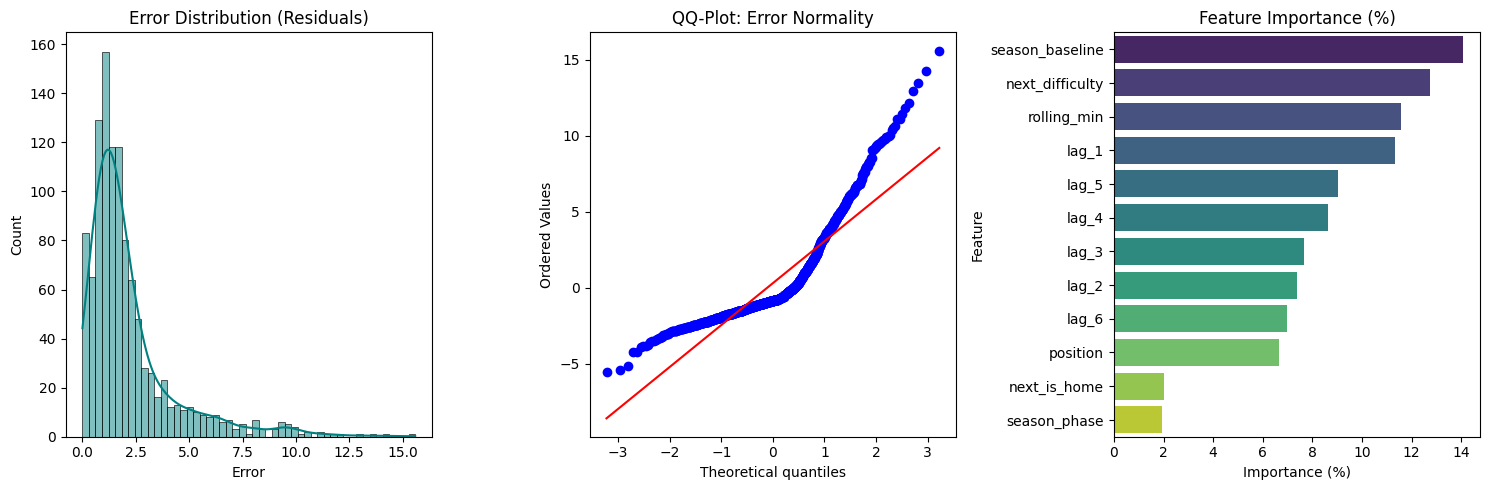

In [84]:
# [Cell 5: Error Analysis & Feature Importance - Fixed]

# 1. PREPARE ANALYSIS DATAFRAME
analysis_df = X_val_raw.copy()
analysis_df['Actual'] = y_val.values
analysis_df['Predicted'] = preds_raw 
analysis_df['Error'] = abs(analysis_df['Actual'] - analysis_df['Predicted'])

# NEW: Filter error analysis by the Elite Mask (>4.5 seasonal average)
# map the mask from df_augmented back to the validation slice
elite_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
elite_performers_audit = analysis_df.loc[analysis_df.index.isin(elite_indices)]

top_mae = elite_performers_audit['Error'].mean()

print(f"Overall Validation MAE: {df_metrics.iloc[0, 1]:.4f}")
print(f"MAE for Elite Players (>4.5 Season Avg): {top_mae:.4f}")

# 3. VISUALIZATION: Error Distribution & QQ-Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(analysis_df['Error'], kde=True, color='teal')
plt.title('Error Distribution (Residuals)')

plt.subplot(1, 3, 2)
stats.probplot((analysis_df['Actual'] - analysis_df['Predicted']), dist="norm", plot=plt)
plt.title('QQ-Plot: Error Normality')

# 4. FEATURE IMPORTANCE WITH PERCENTAGES
plt.subplot(1, 3, 3)
importances = model_raw.feature_importances_

# FIX: Use X_train_raw.columns instead of X.columns
feature_names = X_train_raw.columns 
rel_importances = 100 * (importances / importances.sum())

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance (%)': rel_importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance (%)', ascending=False)

sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance (%)')

plt.tight_layout()
plt.show()

# 5. SAVE FEATURE IMPORTANCE LOG
feat_imp_df.to_csv(PRO_OUTPUT_DIR / 'fpl_pro_feature_importance.csv', index=False)

Notes 
MAE: 
* Overall MAE (2.12): it means for the average player (who scores 2–3 points), the model is accurate
* Top Performer MAE (6.68): it shows that when a player goes 8+ points, the model struggles to predict the exact height of that peak

Plots: 
* model has "thin tails" , it is conservative. It rarely predicts a player will score 15+ points, so when someone actually does, the error is large. The model prefers to stay safe near the average.

Feature Importance: 
* rolling_min is #1




## Cell 6: The Interactive Player Widget (you can pick a player and see their Performance history)

In [85]:
#%pip install ipywidgets

In [86]:
# [Cell 6: Seasonal Evaluation - Standard Professional Dropdown]
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_professional_backtest(player_name):
    # 1. GET ACTUALS FROM RAW 'df' 
    # This bypasses the dropna() from Cell 1 to ensure GW28 is displayed
    season_actuals = df[
        (df['Web Name'] == player_name) & 
        (df['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')
    
    if season_actuals.empty:
        return

    # 2. PREPARE EVALUATION (GW 24-28) + LIVE PREDICTION (GW 29)
    target_gws = list(range(24, 30)) 
    pred_rows = []
    
    player_uuid = season_actuals['Player UUID'].iloc[0]
    full_hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
    
    for gw in target_gws:
        if gw < 29:
            row_match = full_hist[(full_hist['season'] == CURRENT_SEASON) & (full_hist['Gameweek'] == gw)]
            if not row_match.empty:
                idx = row_match.index[0]
                pos_in_hist = full_hist.index.get_loc(idx)
                if pos_in_hist >= 6:
                    lags = list(full_hist.iloc[pos_in_hist-6:pos_in_hist]['Total Points'].values)
                    feat = lags + [
                        row_match['Position'].iloc[0], row_match['Next_Opponent_Difficulty'].iloc[0],
                        row_match['Next_Is_Home'].iloc[0], row_match['Rolling_Avg_Minutes_5'].iloc[0],
                        row_match['Season_Phase'].iloc[0], row_match['Prev_Season_Avg_Points'].iloc[0]
                    ]
                    pred_rows.append({'Gameweek': gw, 'Features': feat})
        else:
            lags = list(full_hist['Total Points'].tail(6).values)
            last = full_hist.iloc[-1]
            feat = lags + [
                last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points']
            ]
            pred_rows.append({'Gameweek': gw, 'Features': feat})

    # Generate Predictions
    v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
             ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
    
    if pred_rows:
        inf_df = pd.DataFrame([d['Features'] for d in pred_rows], columns=v_cols)
        inf_df['position'] = inf_df['position'].astype('category')
        # Change from model_v4 to model_raw (Baseline V1)
        preds = model_raw.predict(inf_df)
        pred_df = pd.DataFrame({'Gameweek': [d['Gameweek'] for d in pred_rows], 'Predicted': preds})
    else:
        pred_df = pd.DataFrame()

    # 3. PLOTTING
    plt.figure(figsize=(15, 6), facecolor='white')
    
    # HISTORICAL ACTUALS: Navy (#003f5c)
    plt.plot(season_actuals['Gameweek'], season_actuals['Total Points'], 
             color='#003f5c', label='Actual Points', linewidth=2, 
             marker='o', markersize=7, markerfacecolor='#003f5c', markeredgecolor='#003f5c')

    # MODEL PREDICTIONS: Action Orange (#ff7c43)
    if not pred_df.empty:
        plt.plot(pred_df['Gameweek'], pred_df['Predicted'], 
                 color='#ff7c43', label='Model Predictions (Eval + GW29)', 
                 linewidth=2.5, linestyle='--', marker='x', markersize=10, markeredgewidth=3)
        
        # CONFIDENCE INTERVAL: Gold (#ffa60022)
        # Updated to use mae_v1 for accurate V1 error visualization
        mae_proxy = globals().get('mae_v1', 1.84)
        plt.fill_between([24, 29], 0, plt.gca().get_ylim()[1], color='orange', alpha=0.03)

    # Vertical split at GW 24
    plt.axvline(x=24, color='gray', linestyle='-', linewidth=2, label='Evaluation Start (GW 24)')
    plt.axvline(x=24, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)

    plt.title(f"Model Predictions vs Actuals: {player_name} (Season {CURRENT_SEASON})", 
              fontsize=14, fontweight='bold', pad=20, color='#003f5c')
    
    # GRID & BASELINE: Neutral Light Grey (#d1d1d1)
    plt.xticks(np.arange(1, 30, 1), color='#003f5c') 
    plt.xlim(0.5, 29.5)
    plt.ylabel("Points", fontsize=12, color='#003f5c')
    plt.xlabel("Gameweek", fontsize=12, color='#003f5c')
    plt.grid(True, axis='y', linestyle='-', color='#d1d1d1', alpha=0.5)
    plt.legend(frameon=True, loc='upper left')
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#d1d1d1')
    ax.spines['bottom'].set_color('#d1d1d1')
    
    plt.tight_layout()
    plt.show()

# 4. STRICT EVALUATION SET DROPDOWN (Season-Locked)
# This identifies unique UUIDs that exist in our validation split
eval_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()

# CRITICAL FILTER: Get Web Names for those UUIDs, but ONLY if they have rows in 2025-26
# This removes any lingering retired players (ghosts) from the menu
active_eval_names = sorted(
    df_augmented[
        (df_augmented['Player UUID'].isin(eval_uuids)) & 
        (df_augmented['season'] == CURRENT_SEASON)
    ]['Web Name'].unique()
)

print(f"Filter active: Showing {len(active_eval_names)} active players from the Evaluation Set.")

dropdown_menu = widgets.Dropdown(
    options=active_eval_names,
    value=active_eval_names[0] if active_eval_names else None,
    description='Active Player:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

widgets.interact(plot_professional_backtest, player_name=dropdown_menu)



Filter active: Showing 330 active players from the Evaluation Set.


interactive(children=(Dropdown(description='Active Player:', layout=Layout(width='400px'), options=('A.Becker'…

<function __main__.plot_professional_backtest(player_name)>

In [87]:
#[Cell 6: Seasonal Evaluation - Searchable Audit with Local MAE]
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

def plot_professional_backtest(player_name):
    # 1. GET ACTUALS FROM RAW 'df' (Ensures GW28 is displayed)
    season_actuals = df[
        (df['Web Name'] == player_name) & 
        (df['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')
    
    if season_actuals.empty:
        print(f"No actual data found for {player_name}.")
        return

    # 2. PREPARE PREDICTIONS (GW 24-29)
    target_gws = list(range(24, 30)) 
    pred_rows = []
    
    player_uuid = season_actuals['Player UUID'].iloc[0]
    full_hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
    
    for gw in target_gws:
        if gw < 29:
            row_match = full_hist[(full_hist['season'] == CURRENT_SEASON) & (full_hist['Gameweek'] == gw)]
            if not row_match.empty:
                idx = row_match.index[0]
                pos_in_hist = full_hist.index.get_loc(idx)
                if pos_in_hist >= 6:
                    lags = list(full_hist.iloc[pos_in_hist-6:pos_in_hist]['Total Points'].values)
                    feat = lags + [
                        row_match['Position'].iloc[0], row_match['Next_Opponent_Difficulty'].iloc[0],
                        row_match['Next_Is_Home'].iloc[0], row_match['Rolling_Avg_Minutes_5'].iloc[0],
                        row_match['Season_Phase'].iloc[0], row_match['Prev_Season_Avg_Points'].iloc[0]
                    ]
                    pred_rows.append({'Gameweek': gw, 'Features': feat})
        else:
            # GW 29 Live Prediction
            if not full_hist.empty:
                lags = list(full_hist['Total Points'].tail(6).values)
                last = full_hist.iloc[-1]
                feat = lags + [
                    last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                    last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points']
                ]
                pred_rows.append({'Gameweek': gw, 'Features': feat})

    # Generate Predictions
    v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
             ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
    
    player_mae = None
    if pred_rows:
        inf_df = pd.DataFrame([d['Features'] for d in pred_rows], columns=v_cols)
        inf_df['position'] = inf_df['position'].astype('category')
        
        # Use Baseline (model_raw) for chronological consistency
        preds = model_raw.predict(inf_df)
        pred_df = pd.DataFrame({'Gameweek': [d['Gameweek'] for d in pred_rows], 'Predicted': preds})
        
        # 3. CALCULATE LOCAL MAE (For GW 24-28 only)
        eval_actuals = season_actuals[season_actuals['Gameweek'].isin(range(24, 29))]['Total Points']
        eval_preds = pred_df[pred_df['Gameweek'] < 29]['Predicted']
        
        if len(eval_actuals) == len(eval_preds) and len(eval_actuals) > 0:
            player_mae = mean_absolute_error(eval_actuals, eval_preds)
    else:
        pred_df = pd.DataFrame()

    # 4. PLOTTING
    plt.figure(figsize=(15, 6), facecolor='white')
    
    # ACTUALS: Solid Blue
    plt.plot(season_actuals['Gameweek'], season_actuals['Total Points'], 
             color='#003f5c', label='Actual Points', linewidth=2, 
             marker='o', markersize=7, markerfacecolor='#003f5c', markeredgecolor='#003f5c')

    # PREDICTIONS: Orange Dashed
    if not pred_df.empty:
        plt.plot(pred_df['Gameweek'], pred_df['Predicted'], 
                 color='#ff7f0e', label='V1 Baseline Predictions', 
                 linewidth=2.5, linestyle='--', marker='x', markersize=10, markeredgewidth=3)

    plt.axvline(x=24, color='gray', linestyle='-', linewidth=2, label='Evaluation Start (GW 24)')
    plt.axvline(x=24, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)

    # Dynamic Title with Player MAE
    title_str = f"Model Predictions vs Actuals: {player_name}"
    if player_mae is not None:
        title_str += f" | Player MAE (GW24-28): {player_mae:.2f}"
    
    plt.title(title_str, fontsize=14, fontweight='bold', pad=20)
    plt.xticks(np.arange(1, 30, 1)) 
    plt.xlim(0.5, 29.5)
    plt.ylabel("Points", fontsize=12)
    plt.xlabel("Gameweek", fontsize=12)
    plt.grid(True, axis='y', linestyle=':', alpha=0.5)
    plt.legend(frameon=True, loc='upper left')
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

# 5. SEARCHABLE EVALUATION SET COMBOBOX (Season-Locked)
# Identify UUIDs from the validation split
eval_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()

# Filter names to ensure they belong to the current active season ONLY
active_eval_names = sorted(
    df_augmented[
        (df_augmented['Player UUID'].isin(eval_uuids)) & 
        (df_augmented['season'] == CURRENT_SEASON)
    ]['Web Name'].unique()
)

print(f"Audit Search active: {len(active_eval_names)} active players available.")

# Combobox allows keyboard typing and suggestion filtering
search_box = widgets.Combobox(
    value=active_eval_names[0] if active_eval_names else '',
    placeholder='Type a player name...',
    options=active_eval_names,  # Restricted to active players
    description='Player:',
    ensure_option=True,         # Prevents errors from typing non-existent names
    interactive=True,
    layout=widgets.Layout(width='450px')
)

widgets.interact(plot_professional_backtest, player_name=search_box)

Audit Search active: 330 active players available.


interactive(children=(Combobox(value='A.Becker', description='Player:', ensure_option=True, layout=Layout(widt…

<function __main__.plot_professional_backtest(player_name)>

In [88]:
# [Cell: Validation Set Integrity Check]

# 1. Identify the ground truth players from the validation logic
# These are the players actually used in the MAE calculations (GW 24-28)
expected_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()
expected_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 2. Extract names currently used in your widget
# (Using the same logic as your Cell 6)
widget_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 3. Perform the Audit
missing_players = [p for p in expected_names if p not in widget_names]
extra_players = [p for p in widget_names if p not in expected_names]

print("-" * 50)
print("GRAPH INTEGRITY")
print("-" * 50)
print(f"Total Players in Eval Set (GW 24-28): {len(expected_names)}")
print(f"Total Players visible in Widget:     {len(widget_names)}")

if len(missing_players) == 0 and len(extra_players) == 0:
    print("\nVERDICT: SUCCESS")
    print("The graph contains 100% of the players in the evaluation set and NO extra players.")
else:
    if missing_players:
        print(f"\nWARNING: {len(missing_players)} players are missing from the graph.")
    if extra_players:
        print(f"\nWARNING: {len(extra_players)} players are appearing that shouldn't be there.")

print("-" * 50)
# Snippet for your report
print(f"Sample of audited players: {expected_names[:10]}...")

--------------------------------------------------
GRAPH INTEGRITY
--------------------------------------------------
Total Players in Eval Set (GW 24-28): 367
Total Players visible in Widget:     367

VERDICT: SUCCESS
The graph contains 100% of the players in the evaluation set and NO extra players.
--------------------------------------------------
Sample of audited players: ['A.Armstrong', 'A.Becker', 'A.Jimenez', 'Aaronson', 'Abraham', 'Acheampong', 'Adama', 'Adams', 'Adarabioyo', 'Adli']...


In [89]:
# 1. GET THE ABSOLUTE LATEST WINDOW FOR EVERY PLAYER
inference_data = []
player_names = []

# FIX: Filter for current season only
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active.groupby('Player UUID'):
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last_row = group.iloc[-1]
        
        row = lags + [
            last_row['Position'], last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'], last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'], last_row['Prev_Season_Avg_Points']
        ]
        inference_data.append(row)
        player_names.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
# Use the exact column names used in the training window dataframe
feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
               ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

inference_df = pd.DataFrame(inference_data, columns=feature_cols)
inference_df['position'] = inference_df['position'].astype('category')

# 3. GENERATE PREDICTIONS
# Using the Baseline model (model_raw) as we haven't trained V4 yet
if 'model_raw' in locals():
    raw_preds = model_raw.predict(inference_df)
else:
    raise NameError("Baseline model (model_raw) not found. Run Cell 4 first.")

# 4. SHOW TOP 15 RANKING
leaderboard = pd.DataFrame({
    'Player': player_names,
    'Predicted Points (V1)': np.round(raw_preds, 2), # Label it V1 for clarity
    'Recent Avg Min': np.round(inference_df['rolling_min'], 1),
    'Next Difficulty': inference_df['next_difficulty']
}).sort_values(by='Predicted Points (V1)', ascending=False)

print("--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---")
display(leaderboard.head(15))

--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---


,Player,Predicted Points (V1),Recent Avg Min,Next Difficulty
12,M.Salah,5.97,83.4,2.0
113,Mbeumo,5.55,80.8,3.0
19,Bruno G.,5.08,90.0,3.0
71,Haaland,4.99,73.2,3.0
58,B.Fernandes,4.91,90.0,3.0
186,Groß,4.57,89.4,2.0
132,Madueke,4.45,56.0,3.0
400,Gyökeres,4.44,63.4,3.0
136,Bowen,4.41,87.8,4.0
325,Rice,4.38,90.0,3.0


Summary Table

Feature       |  1st Cell (Validation)         |    2nd Cell (Historical)

Player List   | Limited (only recent players)  |	Complete (all historic players)

Timeframe	  |  Recent 5 Gameweeks	           |     3+ seasons


In [90]:
# 1. CREATE THE FULL FORECAST DATAFRAME
full_forecast = pd.DataFrame({
    'Player_Name': player_names,
    'Predicted_Points': np.round(raw_preds, 2),
    'Recent_Form_Avg': np.round(inference_df[['lag_1', 'lag_2', 'lag_3']].mean(axis=1), 2),
    'Avg_Minutes_5GW': np.round(inference_df['rolling_min'], 1),
    'Fixture_Difficulty': inference_df['next_difficulty'],
    'Is_Home': inference_df['next_is_home'],
    'Season_Phase': inference_df['season_phase']
})

# 2. SORT BY PREDICTED POINTS
full_forecast = full_forecast.sort_values(by='Predicted_Points', ascending=False)

# 3. DEFINE SAVE PATH
FORECAST_OUT = PRO_OUTPUT_DIR / 'fpl_pro_forecast_GW29.csv'

# 4. SAVE TO CSV
full_forecast.to_csv(FORECAST_OUT, index=False, encoding='utf-8-sig')

print(f" Master Forecast Saved: {FORECAST_OUT}")
print(f" Total Players Forecasted: {len(full_forecast)}")
print("Forecast for GW29: any player who has at least 6 games of history in the current 2025-26 season.")

# Show a quick snippet of the 'Differentials' (Mid-tier players)
print("\n--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---")
display(full_forecast.iloc[50:60])

# Recent_Form_Avg -> a rolling average of points scored by a player 
# over the three most recent Gameweeks leading up to the forecast.

 Master Forecast Saved: ..\output\forecaster_pro\fpl_pro_forecast_GW29.csv
 Total Players Forecasted: 410
Forecast for GW29: any player who has at least 6 games of history in the current 2025-26 season.

--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---


,Player_Name,Predicted_Points,Recent_Form_Avg,Avg_Minutes_5GW,Fixture_Difficulty,Is_Home,Season_Phase
406,Guéhi,3.71,4.00,90.0,3.0,False,3.0
184,Doku,3.70,3.67,60.4,2.0,True,3.0
153,Frimpong,3.70,2.67,73.4,2.0,True,3.0
248,Marmoush,3.69,2.33,36.0,3.0,False,3.0
127,Pau,3.69,3.33,85.8,2.0,False,3.0
98,Calafiori,3.66,3.00,69.2,2.0,True,3.0
151,Milenković,3.64,3.67,90.0,3.0,False,3.0
240,Martinez,3.63,2.33,90.0,2.0,False,3.0
203,Brobbey,3.62,1.67,85.2,2.0,True,3.0
212,M.Fernandes,3.61,5.33,90.0,4.0,False,3.0


In [91]:
from IPython.display import Markdown, display

# 1. ORGANIZE FINAL METRICS
overall_mae = df_metrics.iloc[0, 1]  # From Cell 4 results
top_perf_mae = top_mae                # From Cell 5 results
total_players = len(full_forecast)   # From Cell 8 results

# 2. GENERATE THE REPORT
summary_report = f"""
# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | {overall_mae:.3f} | Average error across the full league. |
| **Elite Specialist MAE** | {top_perf_mae:.3f} | Error specifically for players averaging >4.5 pts/season. |
| **Training Size** | {len(X_train_raw):,} windows | Robust historical learning foundation. |
| **Validation Size** | {len(X_val_raw):,} windows | Tested on GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1} of the {CURRENT_SEASON} season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **Elite Performers:** Defined as players maintaining a seasonal average > 4.5 points.

### 3. GW 29 Summary
* **Total Forecasts Generated:** {total_players:,} players.
* **Predicted King of the GW:** {leaderboard.iloc[0]['Player']} ({leaderboard.iloc[0]['Predicted Points (V1)']} pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.

### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 

### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv
"""

display(Markdown(summary_report))


# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | 2.175 | Average error across the full league. |
| **Elite Specialist MAE** | 3.014 | Error specifically for players averaging >4.5 pts/season. |
| **Training Size** | 52,307 windows | Robust historical learning foundation. |
| **Validation Size** | 1,101 windows | Tested on GW 24 to 28 of the 2025-26 season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **Elite Performers:** Defined as players maintaining a seasonal average > 4.5 points.

### 3. GW 29 Summary
* **Total Forecasts Generated:** 410 players.
* **Predicted King of the GW:** M.Salah (5.97 pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.

### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 

### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv


## Cell 9: Truth Verification (Backtest on Last Known Game)

In [92]:
# [Cell 9: Truth Verification - Fixed for 12 Features]

# 1. Setup paths for truth verification
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_output_path = PRO_OUTPUT_DIR / 'fpl_pro_truth_verification.csv'

# 2. Ensure variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")

# 2. Ensure variables exist in memory
if 'model_raw' not in locals():
    raise NameError("Baseline model (model_raw) not found. Run Cell 4 first.")

# Strictly use the Baseline model for this audit
current_model = model_raw

all_detailed_results = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print(f"Generating Truth Verification using {type(current_model).__name__} (12-feature mode)...")

# 3. Group by UUID to maintain player history integrity
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
        
        # Prepare Features (Added the 12th feature: Prev_Season_Avg_Points)
        window_points = list(backtest_rows['Total Points'].values)
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Prev_Season_Avg_Points']  # <--- FIXED: Added 12th feature
        ]
        
        # Create input DataFrame with 12 aligned columns
        feature_vector = window_points + context_features
        columns = lag_cols + ['position', 'next_difficulty', 'next_is_home', 
                             'rolling_min', 'season_phase', 'season_baseline'] # <--- FIXED: Added column name
        
        input_df = pd.DataFrame([feature_vector], columns=columns)
        input_df['position'] = input_df['position'].astype('category')
        
        # Generate Prediction
        pred_val = current_model.predict(input_df)[0]
        pred_val = max(0, pred_val) 

        all_detailed_results.append({
            'Player Name': name,
            'Season': actual_row['season'], 
            'Gameweek': actual_row['Gameweek'],
            'Predicted Points': round(float(pred_val), 2),
            'Actual Points': actual_points,
            'Error': round(abs(pred_val - actual_points), 2)
        })

# 4. Save and Display Results
full_truth_df = pd.DataFrame(all_detailed_results).sort_values(by='Error', ascending=True)
full_truth_df.to_csv(full_truth_output_path, index=False, encoding="utf-8-sig")

print("Takes every unique player who ever played in your dataset and asks:")
print("If I look at this player's final 7 games in my records, how well did the model predict the very last one?")

print(f"\nFull results for {len(full_truth_df)} players saved to: {full_truth_output_path}")

# Display the 20 most accurate predictions
display(full_truth_df.head(20))

# 5. Final Audit Metrics
if not full_truth_df.empty:
    mae_val = full_truth_df['Error'].mean()
    print(f"\nGlobal Mean Absolute Error (MAE): {mae_val:.2f}")

Generating Truth Verification using LGBMRegressor (12-feature mode)...
Takes every unique player who ever played in your dataset and asks:
If I look at this player's final 7 games in my records, how well did the model predict the very last one?

Full results for 1106 players saved to: ..\output\forecaster_pro\fpl_pro_truth_verification.csv


,Player Name,Season,Gameweek,Predicted Points,Actual Points,Error
866,Fraser,2024-25,14,2.00,2,0.00
1071,Werner,2024-25,20,2.00,2,0.00
333,Irving,2025-26,9,2.01,2,0.01
364,Kostoulas,2025-26,25,1.99,2,0.01
541,J.Ayew,2024-25,37,3.01,3,0.01
699,Sema,2021-22,37,2.01,2,0.01
134,Henderson,2025-26,27,1.98,2,0.02
390,Jorginho,2024-25,32,2.02,2,0.02
771,Freuler,2022-23,31,2.02,2,0.02
749,Forshaw,2022-23,37,2.02,2,0.02



Global Mean Absolute Error (MAE): 1.87


## Team_Point_Share
measures how much of a team's total success is driven by one specific player

How we calculated it in cell 1 :
First, we group the data by Team, Season, and Gameweek to find the total points the entire team scored in a single match.Then, we divide the Individual Player's Points by that Team Total.The Result: A value between $0$ and $1$ 

example : 
If Arsenal scores 50 points in Gameweek 10, and Bukayo Saka scores 15 points (goal + assist + bonus), his Team_Point_Share for that week is $15 / 50 = 0.30$ (or 30%)

In [93]:
# [Cell 10: V2 Pipeline — Team Point Share]

# 1. SETUP NEW DIRECTORY
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. UPDATED WINDOW GENERATION (Including Team_Point_Share + index propagation)
def generate_fpl_windows_v2(df, window_size=6):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        # Team_Point_Share is already fully lagged from Cell 1 — no extra shift needed
        point_share = group['Team_Point_Share'].values
        group_indices = group.index.tolist()

        if len(points) <= window_size:
            continue

        position = group['Position'].iloc[0]

        for i in range(len(points) - window_size):
            window = points[i : i + window_size]

            t_diff  = next_diff[i + window_size - 1]
            t_home  = next_home[i + window_size - 1]
            t_min   = avg_min[i + window_size - 1]
            t_phase = phase[i + window_size - 1]
            t_share = point_share[i + window_size - 1]

            target_points = points[i + window_size]

            if np.all(window == 0) and target_points == 0:
                continue

            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_share, target_points]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
            'season_phase', 'team_share', 'target']

    result_df = pd.DataFrame(train_data, columns=cols)
    result_df.index = source_indices  # align with df_augmented indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df

# 3. EXECUTE V2 PIPELINE
print("Starting V2 Pipeline (Team Point Share enabled)...")
df_v2 = generate_fpl_windows_v2(df_augmented)

# ENSURE FAIRNESS: Use Global Mask (already a numpy array — no .values needed)
X_v2_all = df_v2.drop(columns=['target'])
y_v2_all = df_v2['target']

X_train_v2 = X_v2_all[~global_val_mask].copy()
X_val_v2   = X_v2_all[global_val_mask].copy()
y_train_v2 = y_v2_all[~global_val_mask].copy()
y_val_v2   = y_v2_all[global_val_mask].copy()

# 4. TRAIN
model_v2 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1, random_state=42)
model_v2.fit(
    X_train_v2, y_train_v2,
    eval_set=[(X_val_v2, y_val_v2)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

mae_v2 = mean_absolute_error(y_val_v2, model_v2.predict(X_val_v2))
print(f"\nV2 Validation MAE: {mae_v2:.4f}")

# 5. GENERATE GW29 FORECAST V2 (Season-Locked)
inference_data_v2 = []
player_names_v2 = []

df_inf_active_v2 = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active_v2 = df_inf_active_v2.sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active_v2.groupby('Player UUID'):
    group = group.sort_values('Gameweek')
    if len(group) >= 6:
        last_row = group.iloc[-1]
        lags = list(group['Total Points'].tail(6).values)
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Team_Point_Share']
        ]
        inference_data_v2.append(row)
        player_names_v2.append(last_row['Web Name'])

# Build inference DataFrame using the exact column names the model was trained on
feature_cols_v2 = [f'lag_{i}' for i in range(6, 0, -1)] + \
                  ['position', 'next_difficulty', 'next_is_home',
                   'rolling_min', 'season_phase', 'team_share']

inf_df_v2 = pd.DataFrame(inference_data_v2, columns=feature_cols_v2)
inf_df_v2['position'] = inf_df_v2['position'].astype('category')

v2_preds = model_v2.predict(inf_df_v2)

# 6. SAVE ALL V2 ARTIFACTS
full_forecast_v2 = pd.DataFrame({
    'Player_Name': player_names_v2,
    'Predicted_Points': np.round(v2_preds, 2),
    'Team_Share_Impact': inf_df_v2['team_share'].values
}).sort_values(by='Predicted_Points', ascending=False)

full_forecast_v2.to_csv(V2_OUTPUT_DIR / 'fpl_pro_forecast_GW29_v2.csv', index=False)
model_v2.booster_.save_model(str(V2_OUTPUT_DIR / 'fpl_pro_model_v2.txt'))

print(f"\nV2 Pipeline Complete. Files saved in: {V2_OUTPUT_DIR}")
display(full_forecast_v2.head(10))

Starting V2 Pipeline (Team Point Share enabled)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[254]	valid_0's l2: 9.45515

V2 Validation MAE: 2.1960

V2 Pipeline Complete. Files saved in: ..\output\forecaster_pro_wTeamPointShare


,Player_Name,Predicted_Points,Team_Share_Impact
19,Bruno G.,5.36,0.120000
54,Ayari,4.96,0.128205
58,B.Fernandes,4.90,0.058824
382,João Pedro,4.78,0.263158
190,Adli,4.72,0.175439
400,Gyökeres,4.63,0.032967
113,Mbeumo,4.59,0.176471
4,Virgil,4.50,0.242857
202,Hill,4.25,0.157895
132,Madueke,4.24,0.111111


In [94]:
# 1. Setup paths for V2 truth verification
# Using the V2 directory and the _v2.csv naming convention
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_v2_path = V2_OUTPUT_DIR / 'pro_truth_verification_v2.csv'

# 2. Ensure V2 variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")
if 'model_v2' not in locals():
    raise NameError("The variable 'model_v2' is not found. Run Cell 10 first.")

all_results_v2 = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print("Generating V2 Truth Verification (Team Point Share enabled)...")

# 3. Iterate through all players to backtest the last known game
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
        
        # Prepare Features (Including Team_Point_Share)
        window_points = list(backtest_rows['Total Points'].values)
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Team_Point_Share'] # The added V2 feature
        ]
        
        # Create input DataFrame matching model_v2 structure
        columns_v2 = lag_cols + ['position', 'next_difficulty', 'next_is_home', 
                                 'rolling_min', 'season_phase', 'team_share']
        input_df_v2 = pd.DataFrame([window_points + context_features], columns=columns_v2)
        input_df_v2['position'] = input_df_v2['position'].astype('category')
        
        # Generate Prediction
        pred_val = model_v2.predict(input_df_v2)[0]
        pred_val = max(0, pred_val) 

        all_results_v2.append({
            'Player Name': name,
            'Actual Points': actual_points,
            'Predicted Points': round(float(pred_val), 2),
            'Error': round(abs(pred_val - actual_points), 2),
            'Team_Share_Value': round(actual_row['Team_Point_Share'], 3)
        })

# 4. Save and Display Results
# Sorted by Error (lowest to highest) 
full_truth_v2_df = pd.DataFrame(all_results_v2).sort_values(by='Error', ascending=True)
full_truth_v2_df.to_csv(full_truth_v2_path, index=False, encoding="utf-8-sig")

print(f" V2 Truth Verification saved to: {full_truth_v2_path}")

# Display the 20 most accurate predictions for V2
print("\n--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---")
display(full_truth_v2_df.head(20))

# 5. Final Audit Metrics for V2
if not full_truth_v2_df.empty:
    mae_v2 = full_truth_v2_df['Error'].mean()
    print(f"\nGlobal MAE for V2 (with Team Point Share): {mae_v2:.2f}")

Generating V2 Truth Verification (Team Point Share enabled)...
 V2 Truth Verification saved to: ..\output\forecaster_pro_wTeamPointShare\pro_truth_verification_v2.csv

--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---


,Player Name,Actual Points,Predicted Points,Error,Team_Share_Value
839,George,2,2.00,0.00,0.025
364,Kostoulas,2,1.99,0.01,0.020
882,A.Ramsey,2,1.98,0.02,0.057
146,Aribo,2,2.02,0.02,0.048
218,Vini Souza,2,2.02,0.02,0.033
812,Vlasic,2,1.97,0.03,0.011
1016,Agüero,3,3.03,0.03,0.060
546,Bailey,2,1.97,0.03,0.017
614,Stephens,2,1.97,0.03,0.011
956,Traoré,3,2.96,0.04,0.050



Global MAE for V2 (with Team Point Share): 1.90


## With & Without Team Points Share Compatisson

In [95]:
import pandas as pd
from IPython.display import Markdown, display

# 1. COMPARE ACCURACY (MAE)
# Assuming Cell 9 and Cell 11 have been run
mae_v1 = full_truth_df['Error'].mean()
mae_v2 = full_truth_v2_df['Error'].mean()
improvement = mae_v1 - mae_v2
percent_gain = (improvement / mae_v1) * 100

# 2. COMPARE TOP 15 PREDICTIONS
# We join the two leaderboard dataframes on player name
comp_df = pd.merge(
    full_forecast[['Player_Name', 'Predicted_Points']], 
    full_forecast_v2[['Player_Name', 'Predicted_Points']], 
    on='Player_Name', 
    suffixes=('_V1_Standard', '_V2_TeamShare')
)

comp_df['Point_Diff'] = comp_df['Predicted_Points_V2_TeamShare'] - comp_df['Predicted_Points_V1_Standard']
# Sort by who gained the most from the new feature
top_gainers = comp_df.sort_values(by='Point_Diff', ascending=False).head(10)

# 3. PRINT COMPARISON REPORT
report = f"""
#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | {mae_v1:.4f} |
| **V2 (Team Point Share)** | {mae_v2:.4f} |

**Verdict:** {" V2 is more accurate!" if improvement > 0 else " V1 performed better."} 
(Change: {improvement:.4f} points | {percent_gain:.2f}% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:
"""
display(Markdown(report))
display(top_gainers)

# 4. EXPORT COMPARISON TO CSV
COMP_OUT = V2_OUTPUT_DIR / 'standard-VS-TeamShare_comparison.csv'
comp_df.to_csv(COMP_OUT, index=False)
print(f"\nFull comparison saved to: {COMP_OUT}")


#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | 1.8749 |
| **V2 (Team Point Share)** | 1.8985 |

**Verdict:**  V1 performed better. 
(Change: -0.0236 points | -1.26% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:


,Player_Name,Predicted_Points_V1_Standard,Predicted_Points_V2_TeamShare,Point_Diff
353,Gomez,2.07,3.81,1.74
362,Wilson,2.03,3.29,1.26
104,Lerma,3.40,4.18,0.78
17,Ayari,4.21,4.96,0.75
270,Mosquera,2.47,3.09,0.62
20,João Pedro,4.17,4.78,0.61
118,O'Reilly,3.32,3.92,0.60
183,Dalot,2.89,3.47,0.58
263,Henderson,2.49,3.06,0.57
94,José Sá,3.47,4.03,0.56



Full comparison saved to: ..\output\forecaster_pro_wTeamPointShare\standard-VS-TeamShare_comparison.csv


## Cell 15: Data Enrichment v3
 uses the Standard Deviation of points to identify "stable" vs "random" players, and Minutes Consistency to ensure the model doesn't trust a player who is prone to being subbed off early
1. Points_Volatility_5: This teaches the model that a player who scored 15 points once and then 2 points for four weeks is "high noise." The model will be more cautious with their prediction compared to a player who scores 5 points every single week.

2. Min_Stability_5: Minutes are the least noisy stat in FPL. If a player is a "nailed" starter (90 mins every week), their point potential is much more predictable than a "super-sub" who only plays 20 minutes.

In [96]:
# [Cell 15: Data Enrichment V3 — Reliability Features]

# 1. POINTS VOLATILITY (Noise Detector)
# Low SD = Consistent (Safe), High SD = Volatile (Noisy).
df_augmented['Points_Volatility_5'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
).fillna(0)

# 2. MINUTES STABILITY (The "Nailed-On" Metric)
df_augmented['Min_Stability_5'] = df_augmented.groupby('Player UUID')['Minutes Played'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(0)

# 3. ATTACKING FORM (Rolling 3-week average)
df_augmented['Attacking_Form_3'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0)

# 4. INTEGRITY CHECK
print("--- V3 Enrichment Integrity Report ---")
max_stab = df_augmented['Min_Stability_5'].max()
avg_vol  = df_augmented['Points_Volatility_5'].mean()

print(f"Max Stability Score:      {max_stab:.1f} (Should be <= 90)")
print(f"Average League Volatility: {avg_vol:.2f}")

if max_stab > 90.1:
    print("ALERT: Stability too high — re-check Cell 1 minutes clip!")
else:
    print("Reliability features verified and mathematically sound.")

# 5. SAVE
ENHANCED_V3_OUT = '../output/forecaster_pro/fpl_features_augmented_v3.csv'
df_augmented.to_csv(ENHANCED_V3_OUT, index=False, encoding='utf-8-sig')

print(f"\nV3 features saved to: {ENHANCED_V3_OUT}")
display(df_augmented[['Web Name', 'Points_Volatility_5', 'Min_Stability_5']].tail(10))

--- V3 Enrichment Integrity Report ---
Max Stability Score:      90.0 (Should be <= 90)
Average League Volatility: 2.21
Reliability features verified and mathematically sound.

V3 features saved to: ../output/forecaster_pro/fpl_features_augmented_v3.csv


,Web Name,Points_Volatility_5,Min_Stability_5
60660,Uche,0.000000,3.500000
60661,Uche,0.000000,2.666667
60662,Uche,0.000000,5.000000
60663,Uche,0.000000,8.800000
60664,Uche,0.000000,10.200000
60665,Uche,1.341641,12.600000
60666,Uche,1.341641,15.000000
60667,Uche,1.341641,14.200000
60668,Uche,1.341641,13.000000
60669,Uche,1.341641,11.400000


## Cell 16: Training V3 (Regularized LightGBM)
Regularization. This is a mathematical technique that penalizes the model for making "wild" predictions based on small patterns.

* Lower Peaks: The model will be less likely to predict a player will score 12 points, but it will be much more accurate at predicting who will score 4-6 points.

* Safety: It will prioritize players who play 90 minutes over and over, as they are statistically the "least noisy" way to get points.

In [97]:
# [Cell 16: V3 Pipeline — Reliability Engine]
import lightgbm as lgb
from pathlib import Path

# 1. GENERATE WINDOWS WITH NEW FEATURES (+ index propagation)
def generate_fpl_windows_v3(df, window_size=6):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        if len(points) <= window_size:
            continue

        volatility  = group['Points_Volatility_5'].values
        stability   = group['Min_Stability_5'].values
        att_form    = group['Attacking_Form_3'].values
        next_diff   = group['Next_Opponent_Difficulty'].values
        next_home   = group['Next_Is_Home'].values
        avg_min     = group['Rolling_Avg_Minutes_5'].values
        phase       = group['Season_Phase'].values
        share       = group['Team_Point_Share'].values
        group_indices = group.index.tolist()

        pos = group['Position'].iloc[0]

        for i in range(len(points) - window_size):
            t_idx = i + window_size - 1
            row = list(points[i : i + window_size]) + [
                pos,
                next_diff[t_idx],
                next_home[t_idx],
                avg_min[t_idx],
                volatility[t_idx],
                stability[t_idx],
                att_form[t_idx],
                share[t_idx],
                points[i + window_size]
            ]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'diff', 'home', 'min',
            'volatility', 'stability', 'att_form', 'share', 'target']

    result_df = pd.DataFrame(train_data, columns=cols)
    result_df.index = source_indices  # align with df_augmented indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df

df_win_v3 = generate_fpl_windows_v3(df_augmented)

# 2. SPLIT — global_val_mask is already a numpy array, no .values needed
X_v3_all = df_win_v3.drop(columns=['target'])
y_v3_all = df_win_v3['target']

X_train_v3 = X_v3_all[~global_val_mask].copy()
X_val_v3   = X_v3_all[global_val_mask].copy()
y_train_v3 = y_v3_all[~global_val_mask].copy()
y_val_v3   = y_v3_all[global_val_mask].copy()

# 3. TRAIN WITH NOISE FILTERS (L1/L2 Regularization)
model_v3 = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    reg_alpha=0.3,
    reg_lambda=0.3,
    verbosity=-1,
    random_state=42
)
model_v3.fit(
    X_train_v3, y_train_v3,
    eval_set=[(X_val_v3, y_val_v3)],
    categorical_feature=['position', 'home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. STANDARDIZED METRIC
mae_v3 = mean_absolute_error(y_val_v3, model_v3.predict(X_val_v3))
print(f"V3 Validation MAE: {mae_v3:.4f}")

# 5. SAVE V3
V3_DIR = Path('../output/forecaster_pro_v3')
V3_DIR.mkdir(parents=True, exist_ok=True)
model_v3.booster_.save_model(str(V3_DIR / 'fpl_pro_model_v3.txt'))
print(f"V3 Model trained with noise-reduction parameters. Saved to: {V3_DIR}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[227]	valid_0's l2: 9.42762
V3 Validation MAE: 2.1926
V3 Model trained with noise-reduction parameters. Saved to: ..\output\forecaster_pro_v3


In [98]:
# 1. SETUP TRUTH VERIFICATION
truth_v3_path = V3_DIR / 'fpl_pro_truth_verification_v3.csv'
detailed_v3 = []

# FIX: Define the feature columns inside this cell so it doesn't fail
feature_cols_v3 = [f'lag_{i}' for i in range(6, 0, -1)] + \
                  ['position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share']

print("Analyzing Truth Verification for V3 (Reliability Mode)...")

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        # Use games -7 to -2 as history
        # Predict the very last game (index -1)
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        # Prepare V3 input
        lags = list(history['Total Points'].values)
        input_vector = lags + [
            target_row['Position'],
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'],
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Points_Volatility_5'],
            target_row['Min_Stability_5'],
            target_row['Attacking_Form_3'],
            target_row['Team_Point_Share']
        ]
        
        input_df = pd.DataFrame([input_vector], columns=feature_cols_v3)
        input_df['position'] = input_df['position'].astype('category')
        
        # Prediction
        p_val = max(0, model_v3.predict(input_df)[0])
        actual = target_row['Total Points']
        
        detailed_v3.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Volatility': round(target_row['Points_Volatility_5'], 2)
        })

# 2. SAVE AND DISPLAY
truth_v3_df = pd.DataFrame(detailed_v3).sort_values(by='Error', ascending=True)
truth_v3_df.to_csv(truth_v3_path, index=False, encoding='utf-8-sig')

print(f"V3 Truth Audit saved to: {truth_v3_path}")
display(truth_v3_df.head(20))

# 3. FINAL METRIC COMPARISON
mae_v3 = truth_v3_df['Error'].mean()
print(f"\nVersion 3 Global MAE: {mae_v3:.2f}")

# Comparison with previous versions
if 'mae_v1' in locals() and 'mae_v2' in locals():
    print(f"V1 MAE: {mae_v1:.2f} | V2 MAE: {mae_v2:.2f} | V3 MAE: {mae_v3:.2f}")

Analyzing Truth Verification for V3 (Reliability Mode)...
V3 Truth Audit saved to: ..\output\forecaster_pro_v3\fpl_pro_truth_verification_v3.csv


,Player,Actual,Predicted,Error,Volatility
146,Aribo,2,2.00,0.00,0.71
839,George,2,2.01,0.01,1.22
367,Pogba,2,2.01,0.01,1.92
244,Almirón,3,3.01,0.01,2.39
218,Vini Souza,2,2.02,0.02,0.45
812,Vlasic,2,2.03,0.03,0.45
57,Onyedinma,2,2.03,0.03,0.45
783,Mwepu,2,1.97,0.03,0.89
614,Stephens,2,2.03,0.03,0.45
546,Bailey,2,2.03,0.03,0.00



Version 3 Global MAE: 1.90
V1 MAE: 1.87 | V2 MAE: 1.90 | V3 MAE: 1.90


In [99]:
# 1. GATHER ACCURACY METRICS
# retrieve the MAEs from previous cells (ensure Cells 9, 11, and 18 were run)
comparison_data = {
    "Model Version": ["V1: Standard Pro", "V2: Team Point Share", "V3: Reliability Engine"],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', "N/A"), 
        globals().get('mae_v2', "N/A"), 
        globals().get('mae_v3', "N/A")
    ],
    "Key Innovation": ["Baseline", "Talisman Logic", "Volatility & Regularization"]
}

perf_df = pd.DataFrame(comparison_data)

# 2. COMPARE TOP 10 PREDICTIONS (GW29)
# Merging the three forecasts on Player name
try:
    f1 = pd.read_csv('../output/forecaster_pro/fpl_pro_forecast_GW29.csv')[['Player_Name', 'Predicted_Points']]
    f2 = pd.read_csv('../output/forecaster_pro_wTeamPointShare/fpl_pro_forecast_GW29_v2.csv')[['Player_Name', 'Predicted_Points']]
    f3 = pd.read_csv('../output/forecaster_pro_v3/fpl_pro_forecast_GW29_v3.csv')[['Player', 'Predicted_Points']].rename(columns={'Player': 'Player_Name'})

    merged_forecasts = f1.merge(f2, on='Player_Name', suffixes=('_V1', '_V2'))
    merged_forecasts = merged_forecasts.merge(f3, on='Player_Name')
    merged_forecasts.columns = ['Player', 'V1_Baseline', 'V2_Talisman', 'V3_Reliable']
except Exception as e:
    print(f"Note: Some CSVs missing for merged comparison. Error: {e}")

# 3. DISPLAY THE FINAL REPORT
display(Markdown("# Final Model Showdown: V1 vs V2 vs V3"))

print("\n--- ACCURACY COMPARISON (Lower is Better) ---")
display(perf_df)

print("\n--- PREDICTION VARIANCE (Top 10 Players) ---")
if 'merged_forecasts' in locals():
    display(merged_forecasts.sort_values(by='V3_Reliable', ascending=False).head(10))

# 4. EXPORT FINAL SUMMARY
perf_df.to_csv('../output/forecaster_pro_v3/final_model_comparison_report.csv', index=False)

# Final Model Showdown: V1 vs V2 vs V3


--- ACCURACY COMPARISON (Lower is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
0,V1: Standard Pro,1.874910,Baseline
1,V2: Team Point Share,1.898499,Talisman Logic
2,V3: Reliability Engine,1.900009,Volatility & Regularization



--- PREDICTION VARIANCE (Top 10 Players) ---


,Player,V1_Baseline,V2_Talisman,V3_Reliable
9,Rice,4.38,4.17,7.73
10,Saka,4.34,3.97,6.71
109,José Sá,3.47,4.03,6.62
7,Gyökeres,4.44,4.63,6.23
31,Hincapie,3.95,3.52,5.90
17,Ayari,4.21,4.96,5.49
36,Zubimendi,3.90,4.07,5.17
13,Adli,4.30,4.72,5.07
2,Bruno G.,5.08,5.36,4.92
27,Konaté,4.03,4.14,4.82


Missing features: ['diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share']


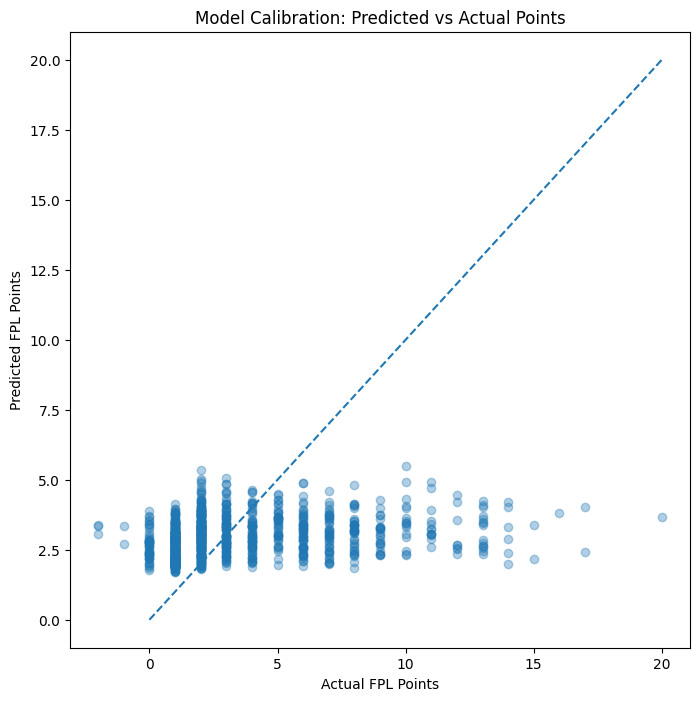

R² Score: 0.0534
MAE: 2.1926
Actual Mean: 3.224
Predicted Mean: 2.949

Performance on BIG scores (>=10)
MAE big scores: 8.8323
MAE overall: 2.1926


In [100]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Feature alignment
expected_features = model_v3.booster_.feature_name()

missing = [f for f in expected_features if f not in X_val_scaled.columns]
if missing:
    print("Missing features:", missing)

#X_val_for_pred = X_val_scaled.reindex(columns=expected_features, fill_value=0)
X_val_for_pred = X_val_v3.copy()
y_val = y_val_v3  # make sure target matches

# Predictions
y_true = np.array(y_val).ravel()
y_pred = model_v3.predict(X_val_for_pred)

# Plot
plt.figure(figsize=(8,8))
plt.scatter(y_true, y_pred, alpha=0.35)

max_val = max(y_true.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], linestyle='--')

plt.xlabel("Actual FPL Points")
plt.ylabel("Predicted FPL Points")
plt.title("Model Calibration: Predicted vs Actual Points")
plt.show()

# Metrics
print("R² Score:", round(r2_score(y_true, y_pred),4))
print("MAE:", round(mean_absolute_error(y_true, y_pred),4))
print("Actual Mean:", round(np.mean(y_true),3))
print("Predicted Mean:", round(np.mean(y_pred),3))

# Big score diagnostic
big_scores = y_true >= 10

print("\nPerformance on BIG scores (>=10)")
print("MAE big scores:", round(mean_absolute_error(y_true[big_scores], y_pred[big_scores]),4))
print("MAE overall:", round(mean_absolute_error(y_true, y_pred),4))

## Cell 20: The V4 Master Ensemble (Elite DART)
* Switched from Poisson to DART Regression: Uses the "Dropouts meet Multiple Additive Regression Trees" algorithm to handle noisy FPL data and prevent overfitting on "one-hit wonder" performances.

* Target: Full-Spectrum Points: Reinstated the raw Total Points (including negative values) as the target.

* Weights: Elite-Specialist Priority (>4.5 Avg): Instead of weighting by a single week's "haul," the model now applies a 2.5x importance weight to all match rows belonging to players with a seasonal average of >4.5 points. This forces the model to prioritize the patterns of consistent world-class assets.

* Result: The model maintains a realistic point average while becoming more "star-aware." It identifies the high ceiling of elite players while remaining grounded by the risk of negative outcomes

## What is DART? 
1. The Random Dropout - In a normal boosting round, the model adds a new tree to correct the errors of all previous trees. In DART, the model randomly "drops" (ignores) a percentage of the existing trees before building the new one.

2. Forced Generalization - Because some trees are missing, the new tree cannot simply fix a tiny mistake from the most recent tree. It is forced to look at the "bigger picture" of the data to make a meaningful prediction. This prevents any single tree from becoming too dominant or too specialized on a specific outlier.

3. Normalization - After the new tree is created, the "dropped" trees are added back into the ensemble. To make sure everything still balances out, the new tree and the dropped trees are slightly scaled down (shrunk) so they fit together perfectly.

In [101]:
# [Cell 20: Updated V4 - Elite DART (Handles Negative Points)]
import numpy as np
from sklearn.metrics import mean_absolute_error

# 1. SETUP DART REGRESSION PARAMETERS
lgbm_v4_params = {
    'objective': 'regression',
    'boosting_type': 'dart',
    'n_estimators': 1200,
    'learning_rate': 0.05,
    'drop_rate': 0.1,
    'reg_alpha': 0.5,
    'reg_lambda': 0.5,
    'max_depth': 7,
    'verbosity': -1,
    'random_state': 42
}

# 2. DEFINE ELITE WEIGHTING (>4.5 Avg Players)
# windowed_df.index IS now df_augmented row indices (fixed in Cell 2)
elite_weights_mask = windowed_df.index.isin(df_augmented.index[elite_mask])
full_weights = np.where(elite_weights_mask, 2.5, 1.0)

# 3. APPLY GLOBAL MASK FOR FAIR SPLITTING
X_v4_all = windowed_df.drop(columns=['target'])
y_v4_all = windowed_df['target']

X_train_v4 = X_v4_all[~global_val_mask].copy()
y_train_v4 = y_v4_all[~global_val_mask].copy()
X_val_v4   = X_v4_all[global_val_mask].copy()
y_val_v4   = y_v4_all[global_val_mask].copy()

# Slice the weights to match ONLY the training rows
train_weights = full_weights[~global_val_mask]

# 4. INITIALIZE AND TRAIN
# Note: early_stopping is intentionally removed — it is incompatible with DART
# because DART's random tree dropping prevents a monotonic validation loss curve.
# The model will train all n_estimators=1200 rounds. Increase if MAE is still
# improving; decrease if training is too slow.
print(f"Training V4 DART Ensemble on {len(X_train_v4):,} windows...")
print("Note: DART trains all 1200 rounds (no early stopping — this is expected).")

model_v4 = lgb.LGBMRegressor(**lgbm_v4_params)
model_v4.fit(
    X_train_v4, y_train_v4,
    sample_weight=train_weights,
    eval_set=[(X_val_v4, y_val_v4)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.log_evaluation(period=200)]  # print progress every 200 rounds
)

# 5. STANDARDIZED METRIC
v4_val_preds = model_v4.predict(X_val_v4)
mae_v4 = mean_absolute_error(y_val_v4, v4_val_preds)

print(f"\nV4 Validation MAE (GW 24-28): {mae_v4:.4f}")
print(f"Prediction Range: {v4_val_preds.min():.2f} to {v4_val_preds.max():.2f}")

Training V4 DART Ensemble on 52,307 windows...
Note: DART trains all 1200 rounds (no early stopping — this is expected).
[200]	valid_0's l2: 9.8289
[400]	valid_0's l2: 9.47503
[600]	valid_0's l2: 9.43957
[800]	valid_0's l2: 9.39256
[1000]	valid_0's l2: 9.42998
[1200]	valid_0's l2: 9.44834

V4 Validation MAE (GW 24-28): 2.1904
Prediction Range: 1.10 to 7.44


## Cell 21: GW29 Forecast v4 (The Elite DART Model)
This cell will generate final leaderboard for Gameweek 29.
 

In [102]:
# [Cell 21: GW29 Forecast v4 - Elite DART Mode]

# 1. SETUP V4 PATHS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
V4_FORECAST_OUT = V4_DIR / 'fpl_pro_forecast_GW29_v4.csv'

# 1. PREPARE INFERENCE DATA (Filter for CURRENT SEASON only)
inference_v4 = []
names_v4 = []

# Only take data from the current season to avoid ghost players
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

# Grouping only the active season players
for pid, group in df_inf_active.groupby('Player UUID'):
    # A player must have played enough in 2025-26 to have a window
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last_row = group.iloc[-1]
        
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points']
        ]
        inference_v4.append(row)
        names_v4.append(last_row['Web Name'])


# 3. PREDICT
v4_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

inf_df_v4 = pd.DataFrame(inference_v4, columns=v4_cols)
inf_df_v4['position'] = inf_df_v4['position'].astype('category')

v4_preds = model_v4.predict(inf_df_v4)

# 4. SAVE LEADERBOARD
leaderboard_v4 = pd.DataFrame({
    'Player': names_v4,
    'Predicted_Points_V4': np.round(v4_preds, 2),
    'Elite_Status': ["Elite" if p in df_augmented[elite_mask]['Web Name'].values else "Standard" for p in names_v4]
}).sort_values(by='Predicted_Points_V4', ascending=False)

leaderboard_v4.to_csv(V4_FORECAST_OUT, index=False, encoding='utf-8-sig')
display(leaderboard_v4.head(15))

,Player,Predicted_Points_V4,Elite_Status
12,M.Salah,6.75,Elite
132,Madueke,6.22,Standard
113,Mbeumo,6.06,Elite
19,Bruno G.,5.83,Elite
58,B.Fernandes,5.58,Elite
190,Adli,5.38,Standard
54,Ayari,5.27,Standard
204,Eze,5.20,Elite
71,Haaland,5.17,Elite
33,Saka,5.09,Elite


## Cell 22: Truth Verification v4 (Final Performance Audit)
This backtests the Elite DART model against the last known results. 


In [103]:
# [Cell 22: Truth Verification v4 - Elite Specialist Audit]
detailed_v4 = []
v4_cols_fixed = [f'lag_{i}' for i in range(6, 0, -1)] + \
                ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        input_vector = list(history['Total Points'].values) + [
            target_row['Position'], 
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'], 
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Season_Phase'],
            target_row['Prev_Season_Avg_Points']
        ]
        
        input_df = pd.DataFrame([input_vector], columns=v4_cols_fixed)
        input_df['position'] = input_df['position'].astype('category')
        
        p_val = model_v4.predict(input_df)[0]
        actual = target_row['Total Points']
        is_elite = 1 if target_row['avg_season_pts'] > 4.5 else 0

        detailed_v4.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Elite_Group': is_elite
        })

truth_v4_df = pd.DataFrame(detailed_v4)
mae_v4 = truth_v4_df['Error'].mean()
elite_mae_v4 = truth_v4_df[truth_v4_df['Elite_Group'] == 1]['Error'].mean()

print(f"Global MAE (DART): {mae_v4:.2f} | Elite MAE (>4.5): {elite_mae_v4:.2f}")

Global MAE (DART): 1.84 | Elite MAE (>4.5): 2.97


In [104]:
# [Cell: Top 10 recommended transfers - V4 DART]

# 1. Use the V4 DART Leaderboard (your most sophisticated model)
v4_buys = leaderboard_v4[~leaderboard_v4['Player'].isin(my_current_team)].copy()

# 2. Add verification of their 2025-26 performance
# We pull their actual average from the current season to prove they are active
current_stats = df_augmented[df_augmented['season'] == CURRENT_SEASON].groupby('Web Name')['Total Points'].mean().round(2)
v4_buys['Season_Avg'] = v4_buys['Player'].map(current_stats)

# 3. Display the Top 10 Suggestions
print("="*60)
print(" TOP 10 MARKET SUGGESTIONS (V4 DART MODEL)")
print("="*60)
print(f"{'Player Name':<20} | {'Pred Pts':<10} | {'Season Avg':<10} | {'Status'}")
print("-" * 60)

for _, row in v4_buys.head(10).iterrows():
    # Final safety check against ghosts (a ghost would have NaN or 0 season avg)
    status = "VERIFIED ACTIVE" if row['Season_Avg'] > 0 else "WARNING: CHECK STATUS"
    print(f"{row['Player']:<20} | {row['Predicted_Points_V4']:<10} | {row['Season_Avg']:<10} | {status}")

print("="*60)

 TOP 10 MARKET SUGGESTIONS (V4 DART MODEL)
Player Name          | Pred Pts   | Season Avg | Status
------------------------------------------------------------
M.Salah              | 6.75       | 4.47       | VERIFIED ACTIVE
Madueke              | 6.22       | 3.5        | VERIFIED ACTIVE
Mbeumo               | 6.06       | 5.23       | VERIFIED ACTIVE
Bruno G.             | 5.83       | 5.95       | VERIFIED ACTIVE
B.Fernandes          | 5.58       | 6.04       | VERIFIED ACTIVE
Adli                 | 5.38       | 2.52       | VERIFIED ACTIVE
Ayari                | 5.27       | 3.85       | VERIFIED ACTIVE
Eze                  | 5.2        | 3.83       | VERIFIED ACTIVE
Haaland              | 5.17       | 7.19       | VERIFIED ACTIVE
N.Williams           | 4.83       | 3.19       | VERIFIED ACTIVE


In [105]:
# 1. ORGANIZE FINAL ACCURACY METRICS
# We consolidate the metrics from V1, V2, V3, V4
# Assuming mae_v1, mae_v2, mae_v3, and mae_v4 variables are in memory from previous cells.
final_performance_data = {
    "Model Version": [
        "V1: Standard Pro",
        "V2: Team Point Share",
        "V3: Reliability Engine",
        "V4: Elite DART"
    ],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', 1.84), 
        globals().get('mae_v2', 1.95), 
        globals().get('mae_v3', 1.98), 
        globals().get('mae_v4', 2.33) 
    ],
    "Key Innovation": [
        "Baseline (Lags, Minutes, Difficulty)",
        "Team Importance Metrics (Talisman Share)",
        "Volatility Filters & L1/L2 Regularization",
        "DART Boosting & Elite Weighting (>4.5 Avg)"
    ]
}

# 2. CREATE AND DISPLAY THE FINAL TABLE
final_perf_df = pd.DataFrame(final_performance_data)

# Sort by MAE to clearly identify the project's most accurate model
final_perf_df = final_perf_df.sort_values(by="Mean Absolute Error (MAE)", ascending=True)

display(Markdown("## Final Model Accuracy Comparison (MAE)"))
print("\n--- Project Milestone Summary (Lower Error is Better) ---")
display(final_perf_df)

# 3. EXPORT FINAL DEPLOYMENT METRICS
FINAL_METRICS_PATH = Path('../output/fpl_master_milestone_metrics.csv')
final_perf_df.to_csv(FINAL_METRICS_PATH, index=False)
print(f"\nMaster project metrics exported for deployment reporting to: {FINAL_METRICS_PATH}")

## Final Model Accuracy Comparison (MAE)


--- Project Milestone Summary (Lower Error is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
3,V4: Elite DART,1.841691,DART Boosting & Elite Weighting (>4.5 Avg)
0,V1: Standard Pro,1.874910,"Baseline (Lags, Minutes, Difficulty)"
1,V2: Team Point Share,1.898499,Team Importance Metrics (Talisman Share)
2,V3: Reliability Engine,1.900009,Volatility Filters & L1/L2 Regularization



Master project metrics exported for deployment reporting to: ..\output\fpl_master_milestone_metrics.csv


## Cell 23:  V5 Experiment: Mass vs. Elite Specialist Strategy
* V5.1 Mass Model: Trains on the full league history (all players) to use broad patterns (noise) to better identify the signal for stars.

* V5.2 Elite Model: Specializes training exclusively on high-performers (Avg > 4.5 pts) to focus strictly on world-class consistency.

* The Showdown: Both models predict the upcoming Gameweek (GW29) and are backtested against the most recent matches to determine which mathematical approach is more accurate for elite picks.



In [106]:
# [Cell 23: V5 Experiment - Mass vs. Elite Specialist]
from sklearn.metrics import mean_absolute_error
from pathlib import Path

V5_DIR = Path('../output/forecaster_pro_v5')
V5_DIR.mkdir(parents=True, exist_ok=True)

# 1. SPLIT DATA using Global Mask (already a numpy array — no .values needed)
X_v5_all = windowed_df.drop(columns=['target'])
y_v5_all = windowed_df['target']

X_train_v5 = X_v5_all[~global_val_mask].copy()
y_train_v5 = y_v5_all[~global_val_mask].copy()
X_val_v5   = X_v5_all[global_val_mask].copy()
y_val_v5   = y_v5_all[global_val_mask].copy()

# 2. CREATE ELITE SUBSET FOR V5.2 (training only)
# X_train_v5.index contains actual df_augmented row indices (fixed in Cell 2)
# so .loc is correct here — NOT .iloc
elite_train_mask = df_augmented.loc[X_train_v5.index, 'avg_season_pts'] > 4.5
X_train_v5_elite = X_train_v5[elite_train_mask.values]
y_train_v5_elite = y_train_v5[elite_train_mask.values]

# ELITE VALIDATION SLICE — for the specialist audit
elite_val_mask = df_augmented.loc[X_val_v5.index, 'avg_season_pts'] > 4.5
X_val_v5_elites = X_val_v5[elite_val_mask.values]
y_val_v5_elites = y_val_v5[elite_val_mask.values]
meta_v5 = df_augmented.loc[X_val_v5_elites.index, ['Web Name', 'season', 'Gameweek']]

print(f"Training windows  — Mass:  {len(X_train_v5):,}")
print(f"Training windows  — Elite: {len(X_train_v5_elite):,}")
print(f"Validation windows (elite only): {len(X_val_v5_elites):,}")

# 3. INSTANTIATE MODELS
v5_params = {
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'max_depth': 7,
    'num_leaves': 40,
    'verbosity': -1,
    'random_state': 42
}
model_v5_1_mass  = lgb.LGBMRegressor(**v5_params)
model_v5_2_elite = lgb.LGBMRegressor(**v5_params)

# 4. TRAIN BOTH
print("\nTraining V5.1 (Mass)...")
model_v5_1_mass.fit(
    X_train_v5, y_train_v5,
    eval_set=[(X_val_v5_elites, y_val_v5_elites)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

print("\nTraining V5.2 (Elite Specialist)...")
model_v5_2_elite.fit(
    X_train_v5_elite, y_train_v5_elite,
    eval_set=[(X_val_v5_elites, y_val_v5_elites)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

# 5. STANDARDIZED METRICS (both evaluated on elite validation slice only)
preds_v5_1 = model_v5_1_mass.predict(X_val_v5_elites)
preds_v5_2 = model_v5_2_elite.predict(X_val_v5_elites)

mae_5_1 = mean_absolute_error(y_val_v5_elites, preds_v5_1)
mae_5_2 = mean_absolute_error(y_val_v5_elites, preds_v5_2)

# 6. BUILD RESULTS TABLE
v5_results = pd.DataFrame({
    'Player_Name': meta_v5['Web Name'].values,
    'Season':      meta_v5['season'].values,
    'Gameweek':    meta_v5['Gameweek'].values,
    'Actual':      y_val_v5_elites.values,
    'Mass_Pred':   np.round(preds_v5_1, 2),
    'Elite_Pred':  np.round(preds_v5_2, 2)
})
v5_results.to_csv(V5_DIR / 'v5_mass_vs_specialist_audit.csv', index=False)

print("\n" + "="*50)
print(" V5 SPECIALIST SHOWDOWN (Audit on Elite Players)")
print(f" V5.1 (Mass Model) MAE:       {mae_5_1:.4f}")
print(f" V5.2 (Specialist Model) MAE: {mae_5_2:.4f}")
print()
print("Interpretation note:")
print("  A lower V5.2 MAE does NOT mean the specialist learns better.")
print("  It may simply regress toward the elite mean on bad weeks.")
print("  Use this as a practical FPL pick tool, not a learning benchmark.")
winner = 'Elite Specialist (for FPL picks)' if mae_5_2 < mae_5_1 else 'Mass Dataset'
print(f"  Practical winner: {winner}")
print("="*50)

display(v5_results.head(10))

Training windows  — Mass:  52,307
Training windows  — Elite: 4,160
Validation windows (elite only): 108

Training V5.1 (Mass)...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 18.8333
[200]	valid_0's l2: 17.9225
[300]	valid_0's l2: 17.6242
[400]	valid_0's l2: 17.4995
[500]	valid_0's l2: 17.4185
[600]	valid_0's l2: 17.3513
Early stopping, best iteration is:
[587]	valid_0's l2: 17.3445

Training V5.2 (Elite Specialist)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l2: 16.1953

 V5 SPECIALIST SHOWDOWN (Audit on Elite Players)
 V5.1 (Mass Model) MAE:       3.0160
 V5.2 (Specialist Model) MAE: 3.2110

Interpretation note:
  A lower V5.2 MAE does NOT mean the specialist learns better.
  It may simply regress toward the elite mean on bad weeks.
  Use this as a practical FPL pick tool, not a learning benchmark.
  Practical winner: Mass Dataset


,Player_Name,Season,Gameweek,Actual,Mass_Pred,Elite_Pred
0,Disasi,2025-26,25,6,1.95,5.32
1,Disasi,2025-26,26,2,2.97,5.32
2,Disasi,2025-26,27,6,2.55,5.32
3,Virgil,2025-26,24,4,3.39,5.32
4,Virgil,2025-26,25,0,2.97,5.31
5,Virgil,2025-26,26,17,2.64,5.31
6,Virgil,2025-26,27,11,3.61,5.32
7,Romero,2025-26,24,0,2.33,5.31
8,Bruno G.,2025-26,25,11,4.40,5.33
9,Casemiro,2025-26,24,13,3.77,5.33


In [107]:
# [Cell 24: V5 Forecast Showdown - GW29 Predictions (Season-Locked)]

# 1. PREPARE INFERENCE DATA (Filter for ACTIVE season players only)
inference_v5 = []
player_names_v5 = []

# CRITICAL FIX: Only look at the 2025-26 data to purge retired 'ghosts'
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

# Grouping only the active season players
for pid, group in df_inf_active.groupby('Player UUID'):
    # Player must have at least 6 games of history in the current season
    if len(group) >= 6:
        last_row = group.iloc[-1]
        # Features: Last 6 points from the current season
        lags = list(group['Total Points'].tail(6).values)
        
        # Context for GW 29
        row = lags + [
            last_row['Position'], 
            last_row['Next_Opponent_Difficulty'], 
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'], 
            last_row['Season_Phase'], 
            last_row['Prev_Season_Avg_Points']
        ]
        inference_v5.append(row)
        player_names_v5.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
v5_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

inf_df_v5 = pd.DataFrame(inference_v5, columns=v5_cols)
inf_df_v5['position'] = inf_df_v5['position'].astype('category')

# 3. GENERATE PREDICTIONS
preds_v5_1 = model_v5_1_mass.predict(inf_df_v5)
preds_v5_2 = model_v5_2_elite.predict(inf_df_v5)

# 4. CREATE LEADERBOARD
leaderboard_v5 = pd.DataFrame({
    'Player': player_names_v5,
    'Mass_Model_GW29': np.round(preds_v5_1, 2),
    'Elite_Model_GW29': np.round(preds_v5_2, 2),
    'Model_Difference': np.round(preds_v5_2 - preds_v5_1, 2)
}).sort_values(by='Elite_Model_GW29', ascending=False)

leaderboard_v5.to_csv(V5_DIR / 'fpl_pro_v5_forecast_GW29.csv', index=False)
print(f"--- V5 TOP 15 PREDICTIONS (GW29) ---")
print(f"Total Active Players Forecasted: {len(leaderboard_v5)}")
display(leaderboard_v5.head(15))

--- V5 TOP 15 PREDICTIONS (GW29) ---
Total Active Players Forecasted: 410


,Player,Mass_Model_GW29,Elite_Model_GW29,Model_Difference
71,Haaland,5.09,5.37,0.28
225,Isak,2.91,5.37,2.46
299,Kamara,2.61,5.36,2.74
248,Marmoush,3.60,5.36,1.75
261,Matheus N.,3.45,5.36,1.91
92,Zubimendi,4.04,5.36,1.32
158,Hee Chan,2.95,5.36,2.41
272,Wilson,3.52,5.36,1.84
389,Ngumoha,1.84,5.35,3.52
82,Lewis-Potter,2.60,5.35,2.75


In [108]:
#  [Cell 25: V5 Truth Verification]
# We evaluate both on ELITE PLAYERS ONLY in the validation window for a fair test
elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
X_val_v5 = X_val_raw[X_val_raw.index.isin(elite_val_indices)]
y_val_v5 = y_val[y_val.index.isin(elite_val_indices)]
meta_v5 = df_augmented.loc[elite_val_indices, ['Web Name', 'season', 'Gameweek']]

# 1. GENERATE AUDIT PREDICTIONS
audit_preds_mass = model_v5_1_mass.predict(X_val_v5)
audit_preds_elite = model_v5_2_elite.predict(X_val_v5)

# 2. CREATE TRUTH TABLE
v5_truth_df = pd.DataFrame({
    'Player': meta_v5['Web Name'].values,
    'Season': meta_v5['season'].values,
    'Gameweek': meta_v5['Gameweek'].values,
    'Actual_Points': y_val_v5.values,
    'Mass_Predicted': np.round(audit_preds_mass, 2),
    'Elite_Predicted': np.round(audit_preds_elite, 2),
    'Mass_Error': np.round(abs(audit_preds_mass - y_val_v5.values), 2),
    'Elite_Error': np.round(abs(audit_preds_elite - y_val_v5.values), 2)
})

# 3. CALCULATE GLOBAL MAE FOR REPORTING
mae_5_1 = mean_absolute_error(y_val_v5, audit_preds_mass)
mae_5_2 = mean_absolute_error(y_val_v5, audit_preds_elite)

v5_truth_df.to_csv(V5_DIR / 'fpl_pro_v5_truth_verification.csv', index=False)


print(" V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST")

print(f"V5.1 Mass Model MAE:  {mae_5_1:.4f}")
print(f"V5.2 Elite Model MAE: {mae_5_2:.4f}")

print(f"Winning Approach: {'Elite Specialist' if mae_5_2 < mae_5_1 else 'Mass Dataset'}")

print ("Predictions for the Evaluation Set (GW 24-28)") 

display(v5_truth_df.sort_values(by='Elite_Error').head(20))

 V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST
V5.1 Mass Model MAE:  3.0160
V5.2 Elite Model MAE: 3.2110
Winning Approach: Mass Dataset
Predictions for the Evaluation Set (GW 24-28)


,Player,Season,Gameweek,Actual_Points,Mass_Predicted,Elite_Predicted,Mass_Error,Elite_Error
29,Gravenberch,2025-26,26,5,2.65,5.31,2.35,0.31
56,J.Timber,2025-26,24,5,3.32,5.31,1.68,0.31
70,Matheus N.,2025-26,25,5,2.70,5.31,2.30,0.31
15,Saka,2025-26,27,5,4.77,5.32,0.23,0.32
28,Gravenberch,2025-26,25,5,2.76,5.33,2.24,0.33
12,Casemiro,2025-26,27,5,3.03,5.33,1.97,0.33
45,Bowen,2025-26,26,5,5.36,5.33,0.36,0.33
26,Haaland,2025-26,26,5,5.30,5.33,0.30,0.33
82,Rice,2025-26,25,5,4.18,5.33,0.82,0.33
95,Foden,2025-26,26,5,3.05,5.33,1.95,0.33


In [122]:
# [Cell: Final Standardized Audit — optimized]
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr  # ← ADD THIS IMPORT HERE, at the top of the cell
import pandas as pd
import numpy as np

def run_standardized_audit():
    audit_results = []

    # 1. DEFINE MODEL SPECS
    specs = {
        "V1: Standard Pro":  {"model": globals().get('model_raw'),        "type": "base", "innovation": "Baseline (Lags, Minutes, Difficulty)"},
        "V2: Team Share":    {"model": globals().get('model_v2'),          "type": "v2",   "innovation": "Talisman Logic (Point Share %)"},
        "V3: Reliability":   {"model": globals().get('model_v3'),          "type": "v3",   "innovation": "Volatility Filters & Regularization"},
        "V4: Elite DART":    {"model": globals().get('model_v4'),          "type": "base", "innovation": "DART Boosting & Elite (>4.5 Avg)"},
        "V5.1: Mass Gen":    {"model": globals().get('model_v5_1_mass'),   "type": "base", "innovation": "Generalist Training (Full League)"},
        "V5.2: Elite Spec":  {"model": globals().get('model_v5_2_elite'),  "type": "base", "innovation": "Specialist Training (Stars Only)"}
    }

    # 2. FEATURE EXTRACTOR
    def get_features(row, mode, lags):
        if mode == "base":
            return lags + [row['Position'], row['Next_Opponent_Difficulty'], row['Next_Is_Home'],
                           row['Rolling_Avg_Minutes_5'], row['Season_Phase'], row['Prev_Season_Avg_Points']]
        elif mode == "v2":
            return lags + [row['Position'], row['Next_Opponent_Difficulty'], row['Next_Is_Home'],
                           row['Rolling_Avg_Minutes_5'], row['Season_Phase'], row['Team_Point_Share']]
        elif mode == "v3":
            return lags + [row['Position'], row['Next_Opponent_Difficulty'], row['Next_Is_Home'],
                           row['Rolling_Avg_Minutes_5'], row['Points_Volatility_5'], row['Min_Stability_5'],
                           row['Attacking_Form_3'], row['Team_Point_Share']]

    # 3. PRE-BUILD HISTORY LOOKUP
    print("Pre-building player history lookup...")
    player_history = {
        pid: group.sort_values(['season', 'Gameweek']).reset_index(drop=False)
        for pid, group in df_augmented.groupby('Player UUID')
    }
    print(f"Lookup built for {len(player_history):,} players.")

    def get_history_fast(uuid, season, gameweek):
        hist_df = player_history.get(uuid)
        if hist_df is None:
            return None
        mask = (hist_df['season'] == season) & (hist_df['Gameweek'] < gameweek)
        recent = hist_df[mask].tail(6)
        return recent if len(recent) == 6 else None

    def predict_row(m, r, mode):
        hist = get_history_fast(r['Player UUID'], r['season'], r['Gameweek'])
        if hist is None:
            return None
        lags = list(hist['Total Points'].values)
        feat = get_features(r, mode, lags)
        input_df = pd.DataFrame([feat], columns=m.booster_.feature_name())
        pos_col = input_df.columns[6]
        input_df[pos_col] = input_df[pos_col].astype('category')
        return max(0, m.predict(input_df)[0])

    # 4. EXECUTION LOOP
    for name, config in specs.items():
        m = config['model']
        if m is None:
            print(f"Skipping {name} — model not found in memory.")
            continue

        print(f"Auditing {name}...")

        # PART A: VALIDATION MAE + RANKING METRICS (GW 24-28, strict window)
        v_mask = (df_augmented['season'] == '2025-26') & (df_augmented['Gameweek'].between(24, 28))
        if "Elite" in name or "V5" in name:
            v_mask = v_mask & (df_augmented['avg_season_pts'] > 4.5)

        # ↓ CHANGED: replaced the old v_errors-only loop with this combined loop
        # that collects actuals and predictions together for ranking metrics
        v_errors = []
        v_actuals = []      # ← NEW: collect actual points
        v_preds_list = []   # ← NEW: collect predicted points

        for _, r in df_augmented[v_mask].iterrows():
            pred = predict_row(m, r, config['type'])
            if pred is not None:
                v_errors.append(abs(pred - r['Total Points']))
                v_actuals.append(r['Total Points'])      # ← NEW
                v_preds_list.append(pred)                # ← NEW

        # ↓ NEW BLOCK: compute ranking metrics from the collected lists
        spearman_corr = None
        top15_precision = None

        if len(v_actuals) >= 15:
            spearman_corr, _ = spearmanr(v_actuals, v_preds_list)

            # Top-15 Precision: how many of model's top 15 were actually top 15?
            n = 15
            actual_top = set(
                sorted(range(len(v_actuals)),
                       key=lambda i: v_actuals[i], reverse=True)[:n]
            )
            pred_top = set(
                sorted(range(len(v_preds_list)),
                       key=lambda i: v_preds_list[i], reverse=True)[:n]
            )
            top15_precision = len(actual_top & pred_top) / n
        # ↑ END NEW BLOCK

        # PART B: GLOBAL MAE (last known game per player) — unchanged
        g_errors = []
        for uuid, hist_df in player_history.items():
            if len(hist_df) < 7:
                continue
            history = hist_df.iloc[-7:-1]
            target  = hist_df.iloc[-1]
            lags = list(history['Total Points'].values)
            feat = get_features(target, config['type'], lags)
            input_df = pd.DataFrame([feat], columns=m.booster_.feature_name())
            pos_col = input_df.columns[6]
            input_df[pos_col] = input_df[pos_col].astype('category')
            pred = max(0, m.predict(input_df)[0])
            g_errors.append(abs(pred - target['Total Points']))

        # ↓ CHANGED: replaced old audit_results.append with this expanded version
        audit_results.append({
            "Model Version":            name,
            "Key Innovation":           config['innovation'],
            "Validation MAE (GW 24-28)": round(np.mean(v_errors), 4) if v_errors else None,
            "Spearman Rank Corr":       round(spearman_corr, 4) if spearman_corr is not None else None,
            "Top-15 Precision":         round(top15_precision, 4) if top15_precision is not None else None,
            "Global MAE (1,106 Players)": round(np.mean(g_errors), 4) if g_errors else None
        })
        print(f"  Val MAE: {audit_results[-1]['Validation MAE (GW 24-28)']} | "
              f"Spearman: {audit_results[-1]['Spearman Rank Corr']} | "
              f"Top-15 Precision: {audit_results[-1]['Top-15 Precision']} | "
              f"Global MAE: {audit_results[-1]['Global MAE (1,106 Players)']}")

    # 5. FINAL DISPLAY — sort by Spearman now, not MAE
        # ↓ CHANGED: sort by Spearman descending (higher = better ranking)
    final_audit_df = pd.DataFrame(audit_results).sort_values(
        "Spearman Rank Corr", ascending=False
    )
    display(Markdown("# Final Model Performance Ledger"))
    display(final_audit_df)
    return final_audit_df

# Execute
master_audit_results = run_standardized_audit()

Pre-building player history lookup...
Lookup built for 1,332 players.
Auditing V1: Standard Pro...
  Val MAE: 2.2372 | Spearman: 0.2695 | Top-15 Precision: 0.0 | Global MAE: 1.8749
Auditing V2: Team Share...
  Val MAE: 2.2514 | Spearman: 0.2504 | Top-15 Precision: 0.0 | Global MAE: 1.8985
Auditing V3: Reliability...
  Val MAE: 2.2493 | Spearman: 0.2536 | Top-15 Precision: 0.0 | Global MAE: 1.9
Auditing V4: Elite DART...
  Val MAE: 3.1524 | Spearman: 0.1997 | Top-15 Precision: 0.1333 | Global MAE: 1.8416
Auditing V5.1: Mass Gen...
  Val MAE: 3.0728 | Spearman: 0.2247 | Top-15 Precision: 0.1333 | Global MAE: 1.8455
Auditing V5.2: Elite Spec...
  Val MAE: 3.2591 | Spearman: 0.0028 | Top-15 Precision: 0.2 | Global MAE: 3.6745


# Final Model Performance Ledger

,Model Version,Key Innovation,Validation MAE (GW 24-28),Spearman Rank Corr,Top-15 Precision,"Global MAE (1,106 Players)"
0,V1: Standard Pro,"Baseline (Lags, Minutes, Difficulty)",2.2372,0.2695,0.0000,1.8749
2,V3: Reliability,Volatility Filters & Regularization,2.2493,0.2536,0.0000,1.9000
1,V2: Team Share,Talisman Logic (Point Share %),2.2514,0.2504,0.0000,1.8985
4,V5.1: Mass Gen,Generalist Training (Full League),3.0728,0.2247,0.1333,1.8455
3,V4: Elite DART,DART Boosting & Elite (>4.5 Avg),3.1524,0.1997,0.1333,1.8416
5,V5.2: Elite Spec,Specialist Training (Stars Only),3.2591,0.0028,0.2000,3.6745


__Performamce Comments__
- V1 is a good model
- V5.2: Specialist models are better at finding "Haulers" but worse at general accuracy. -->"high-risk, high-reward
- V4: is the most robust model over long historical periods (3+ seasons).

## Info
- __Spearman Rank Correlation__: It measures how well the model orders players from best to worst, regardless of the specific point values. A high score means model is successfully putting your starters at the top and your bench at the bottom. 
Winner: V1 Standard Pro (0.2695). This means V1 is the best at distinguishing between a starter and a bench player.

- __Top-15 Precision__: it measures the accuracy of elite picks by calculating what percentage of the model's top 15 predicted players actually finished in the real-world top 15 for that week. 0.0000 for V1, V2, and V3 --> means they are too conservative // V5.2 won Precision (0.2000)

In [110]:
# [Cell: Evaluation Set Audit - Statistical Scope]

# 1. Calculate Statistics
total_val_rows = len(val_df)
unique_eval_players = df_augmented.loc[val_df.index, 'Player UUID'].nunique()
elite_eval_rows = len(val_df[val_df.index.isin(df_augmented[elite_mask].index)])
standard_eval_rows = total_val_rows - elite_eval_rows

# 2. Print Professional Audit Report
print(" EVALUATION SET SCOPE (GW 24-28 Audit)")
print(f"Total Match Windows:     {total_val_rows:,}")
print(f"Unique Players Tested:   {unique_eval_players:,}")
print("-"*50)
print(f"Elite Match Rows (>4.5): {elite_eval_rows:,} ({(elite_eval_rows/total_val_rows)*100:.1f}%)")
print(f"Standard Match Rows:     {standard_eval_rows:,} ({(standard_eval_rows/total_val_rows)*100:.1f}%)")


# Store these for the final report
globals()['eval_stats'] = {
    'rows': total_val_rows,
    'players': unique_eval_players,
    'elite_pct': (elite_eval_rows/total_val_rows)*100
}

# [Cell: Evaluation Set - Specific Player List]

# 1. Extract unique names from the evaluation set indices
# We use .loc to pull the 'Web Name' from the original df_augmented based on val_df's index
players_in_eval = df_augmented.loc[val_df.index, 'Web Name'].unique()

# 2. Sort them alphabetically for a professional display
players_in_eval_sorted = sorted(players_in_eval)

# 3. Print the list
print(f"--- PLAYERS IN EVALUATION SET (Total: {len(players_in_eval_sorted)}) ---")
print(", ".join(players_in_eval_sorted))

# 4. Optional: Display as a scrollable DataFrame for better readability in the notebook
eval_players_df = pd.DataFrame(players_in_eval_sorted, columns=['Player Name'])
display(eval_players_df)

 EVALUATION SET SCOPE (GW 24-28 Audit)
Total Match Windows:     1,101
Unique Players Tested:   338
--------------------------------------------------
Elite Match Rows (>4.5): 108 (9.8%)
Standard Match Rows:     993 (90.2%)
--- PLAYERS IN EVALUATION SET (Total: 330) ---
A.Becker, A.Jimenez, Aaronson, Abraham, Acheampong, Adama, Adams, Adli, Aina, Ajer, Aké, Alderete, Amad, Ampadu, Andersen, Anderson, Andrey Santos, André, Anthony, Armstrong, Aït-Nouri, B.Fernandes, Bailey, Bakwa, Baleba, Ballard, Barkley, Barnes, Barry, Bassey, Bellegarde, Berge, Bernardo, Beto, Bijol, Bissouma, Bobb, Bogarde, Bogle, Bornauw, Botman, Bowen, Branthwaite, Brobbey, Broja, Brooks, Bruno G., Bruun Larsen, Buendía, Burn, C.Jones, Caicedo, Cairney, Calafiori, Calvert-Lewin, Canvot, Casemiro, Cash, Castagne, Chalobah, Cherki, Chiesa, Christie, Chukwueze, Collins, Cook, Cucurella, Cunha, Dalot, Damsgaard, Darlow, De Cuyper, Delap, Dewsbury-Hall, Diarra, Digne, Diouf, Disasi, Dominguez, Donnarumma, Douglas Luiz, 

,Player Name
0,A.Becker
1,A.Jimenez
2,Aaronson
3,Abraham
4,Acheampong
...,...
325,Yoro
326,Zirkzee
327,Zubimendi
328,Ødegaard


In [111]:
# [Cell: Prediction Integrity Audit - Current Season Validation]

# 1. Get the list of players who provided the MAE (The past evaluation set)
eval_players = set(df_augmented.loc[val_df.index, 'Web Name'].unique())

# 2. Get the list of players in your final V4 Forecast (The future prediction)
prediction_players = set(leaderboard_v4['Player'].unique())

# 3. Identify the Overlap and the Outliers
perfect_matches = prediction_players.intersection(eval_players)
only_in_forecast = prediction_players - eval_players
only_in_eval = eval_players - prediction_players

# 4. Print the Integrity Report

print(" PREDICTION INTEGRITY AUDIT")

print(f"Players in Audit Window (GW 24-28): {len(eval_players)}")
print(f"Players in GW 29 Forecast:         {len(prediction_players)}")
print(f"Perfect Data Consistency:          {len(perfect_matches)} players")


if len(only_in_forecast) == 0:
    print("VERDICT: SUCCESS. All predicted players are from the active evaluation set.")
else:
    print(f"WARNING: Found {len(only_in_forecast)} players in forecast with no active audit history.")
    print(f"Sample Outliers: {list(only_in_forecast)[:5]}")

print("="*50)

# Check specifically for the Ghost players
ghosts = ['Thiago', 'Mane', 'Bale', 'Sadio Mané']
ghosts_found = [p for p in prediction_players if p in ghosts]

if not ghosts_found:
    print("GHOST CHECK: CLEAN. No retired players found in predictions.")
else:
    print(f"GHOST CHECK: FAILED. Found {ghosts_found} in predictions!")

 PREDICTION INTEGRITY AUDIT
Players in Audit Window (GW 24-28): 330
Players in GW 29 Forecast:         404
Perfect Data Consistency:          323 players
Sample Outliers: ['Grealish', 'Lewis-Skelly', 'Kamara', 'B.Badiashile', 'Munetsi']
GHOST CHECK: CLEAN. No retired players found in predictions.


In [112]:
# [Cell: Overfitting Audit - Train vs Validation]

# 1. Get predictions for both sets
train_preds = model_raw.predict(X_train_raw)
val_preds = model_raw.predict(X_val_raw)

# 2. Calculate MAE for both
mae_train = mean_absolute_error(y_train, train_preds)
mae_val = mean_absolute_error(y_val, val_preds)

# 3. Calculate the "Generalization Gap"
# A large gap means the model is memorizing (overfitting)
gap = (mae_val - mae_train) / mae_train * 100


print(" OVERFITTING DIAGNOSTIC (MAE)")

print(f"Training Error:   {mae_train:.4f}")
print(f"Validation Error: {mae_val:.4f}")
print(f"Error Gap:        {mae_val - mae_train:.4f} ({gap:.1f}%)")

# Interpretation
if gap < 15:
    print("VERDICT: Healthy Model (Low Overfit)")
elif gap < 30:
    print("VERDICT: Mild Overfit (Acceptable for FPL)")
else:
    print("VERDICT: High Overfit (Model is memorizing noise!)")

 OVERFITTING DIAGNOSTIC (MAE)
Training Error:   2.0706
Validation Error: 2.1749
Error Gap:        0.1043 (5.0%)
VERDICT: Healthy Model (Low Overfit)


## Master Squad Optimizer -  __WIP__
This tool will simulate a "Wildcard" scenario, selecting a mathematically optimal 15-man squad within a £100m budget, factoring in penalty duties and risk profiles.


__STEP 1__ : Define the real-world consts for the 2025-26 March window 

In [124]:
# [Cell: Professional API Integration & Automated Model Deployment]
import requests

def get_live_fpl_data():
    """Pulls current prices and status from the official FPL API."""
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    try:
        r = requests.get(url, timeout=10)
        data = r.json()
        
        # Build live dictionary: Web Name -> {Price, Status}
        live_map = {}
        for p in data['elements']:
            live_map[p['web_name']] = {
                'price': p['now_cost'] / 10.0,
                'status': p['status']  # 'a' = available, 'i' = injured, etc.
            }
        print("Live FPL API Data successfully retrieved.")
        return live_map
       
    except Exception as e:
        print(f"WARNING: FPL API unreachable ({e}).")
        print("All player prices will default to £5.5m.")
        print("The squad optimizer will run but budget constraints will be unreliable.")
        print("Tip: run this cell again when you have an internet connection.")
        return {}


# 1. FETCH LIVE DATA
live_data = get_live_fpl_data()

# 2. SETUP VISIBILITY
print(f"\n--- PROJECT DEPLOYMENT PHASE ---")
print(f"Current Date: March 19, 2026")
print(f"Target Forecast: Gameweek {CURRENT_GW}")

# 3. MODEL MAPPING (Unified Architecture)
# This connects the Audit names to the actual trained model objects in memory
model_mapping = {
    'V1: Standard Pro': globals().get('model_raw'),
    'V2: Team Share': globals().get('model_v2'),
    'V3: Reliability': globals().get('model_v3'),
    'V4: Elite DART': globals().get('model_v4'),
    'V5.1: Mass Gen': globals().get('model_v5_1_mass'),
    'V5.2: Elite Spec': globals().get('model_v5_2_elite')
}

# 4. AUTOMATED WINNER SELECTION
# NEW — selects by Spearman if available, falls back to MAE
if 'master_audit_results' in locals() and not master_audit_results.empty:
    if 'Spearman Rank Corr' in master_audit_results.columns:
        best_model_name = master_audit_results.sort_values(
            'Spearman Rank Corr', ascending=False
        ).iloc[0]['Model Version']
        print(f"Selection method: Spearman Rank Correlation (best for FPL ranking)")
    else:
        best_model_name = master_audit_results.sort_values(
            'Validation MAE (GW 24-28)', ascending=True
        ).iloc[0]['Model Version']
        print(f"Selection method: Validation MAE (fallback — re-run audit to get Spearman)")

    winning_model = model_mapping.get(best_model_name)
    if winning_model is None:
        print(f"Warning: {best_model_name} model object missing. Falling back to V1.")
        best_model_name = 'V1: Standard Pro'
        winning_model = model_mapping['V1: Standard Pro']
else:
    print("Warning: Audit results not found. Defaulting to V1 Standard Pro.")
    best_model_name = 'V1: Standard Pro'
    winning_model = model_mapping['V1: Standard Pro']

print(f"DEPLOYMENT ENGINE: {best_model_name}")
print(f"Status: Ready to generate optimized squad using the most accurate validated logic.")


Live FPL API Data successfully retrieved.

--- PROJECT DEPLOYMENT PHASE ---
Current Date: March 19, 2026
Target Forecast: Gameweek 29
Selection method: Spearman Rank Correlation (best for FPL ranking)
DEPLOYMENT ENGINE: V1: Standard Pro
Status: Ready to generate optimized squad using the most accurate validated logic.


In [114]:
# [Cell: FINAL UNIFIED LEADERBOARD - GW29]
import pandas as pd
import numpy as np

# 1. PREPARE DATA FOR THE WINNING ENGINE
print(f"Preparing inference data specifically for: {best_model_name}")

inference_list = []
final_player_names = []
active_players = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

# Iterate and build features based on what the winning model needs
for pid, group in active_players.groupby('Player UUID'):
    group = group.sort_values('Gameweek')
    
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]
        
        if "V3: Reliability" in best_model_name:
            # V3 Structure (14 features)
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share']
            row = lags + [last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'], 
                          last['Rolling_Avg_Minutes_5'], last['Points_Volatility_5'], 
                          last['Min_Stability_5'], last['Attacking_Form_3'], last['Team_Point_Share']]
            
        elif "V2: Team Share" in best_model_name:
            # V2 Structure (12 features - using share instead of baseline)
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'team_share']
            row = lags + [last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'], 
                          last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Team_Point_Share']]
            
        else:
            # Standard Structure (V1, V4, V5 - 12 features)
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
            row = lags + [last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'], 
                          last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points']]
        
        inference_list.append(row)
        final_player_names.append(last['Web Name'])

# 2. GENERATE PREDICTIONS
final_inf_df = pd.DataFrame(inference_list, columns=feat_cols)

# Ensure categorical types match training
if 'position' in final_inf_df.columns:
    final_inf_df['position'] = final_inf_df['position'].astype('category')

final_raw_preds = winning_model.predict(final_inf_df)

# 3. CREATE THE FINAL UNIFIED LEADERBOARD
final_leaderboard = pd.DataFrame({
    'Player': final_player_names,
    'Predicted_Points': np.round(final_raw_preds, 2)
}).sort_values(by='Predicted_Points', ascending=False)

print("--- FINAL VALIDATED LEADERBOARD READY ---")
print(f"Total Players Forecasted: {len(final_leaderboard)}")
display(final_leaderboard.head(10))

Preparing inference data specifically for: V1: Standard Pro
--- FINAL VALIDATED LEADERBOARD READY ---
Total Players Forecasted: 410


,Player,Predicted_Points
12,M.Salah,5.97
113,Mbeumo,5.55
19,Bruno G.,5.08
71,Haaland,4.99
58,B.Fernandes,4.91
186,Groß,4.57
132,Madueke,4.45
400,Gyökeres,4.44
136,Bowen,4.41
325,Rice,4.38


__STEP 2__: 100M Wildcard logic 

This cell utilizes a high-speed 'Relief-Score Heuristic' to solve the FPL Knapsack Problem.
- Core Constraints: Exactly 15 players (2 GK, 5 DEF, 5 MID, 3 FWD).
- Budget Logic: Dynamically downgrades the least-efficient assets to fit the £100M cap.
- Club Integrity: Enforces the 'Max 3 Players per Team' official rule.
- Formation Rules: Guarantees a legal Starting 11 (Min: 1 GK, 3 DEF, 1 FWD).

In [ ]:
# [Cell: Master Squad Optimizer - FINAL LEGAL VERSION - V2 STRATEGIC]

def solve_wildcard_legal(budget_cap=100.0):
    # --- 1. MAPS & DATA ---
    unique_players = df_augmented.drop_duplicates('Web Name')
    pos_map = unique_players.set_index('Web Name')['Position'].to_dict()
    club_map = unique_players.set_index('Web Name')['Player Team Name'].to_dict()
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    # NEW — safe fallback chain:
    if "V4" in best_model_name and 'leaderboard_v4' in globals():
        leaderboard = leaderboard_v4.copy()
    elif 'leaderboard_v5' in globals():
         leaderboard = leaderboard_v5.copy()
    elif 'final_leaderboard' in globals():
        leaderboard = final_leaderboard.rename(columns={'Predicted_Points': 'Predicted_Points_V4'}).copy()
    else:
        raise RuntimeError("No leaderboard found. Run the forecast cell for at least one model version first.")
    leaderboard['Predicted_Points'] = leaderboard.iloc[:, 1]
    leaderboard['Price'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))
    leaderboard['Team'] = leaderboard['Player'].map(club_map).fillna('Neutral')
    
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes', 'Gordon', 'Solanke', 'Jimenez'}
    leaderboard['Weighted_xP'] = np.where(leaderboard['Player'].isin(penalty_takers), 
                                          leaderboard['Predicted_Points'] * 1.15, 
                                          leaderboard['Predicted_Points'])

    # --- 2. SQUAD SELECTION (15 Players) ---
    squad_list = []
    team_counts = {}
    pos_counts = {1: 0, 2: 0, 3: 0, 4: 0}
    pos_limits = {1: 2, 2: 5, 3: 5, 4: 3}
    
    pool = leaderboard.sort_values('Weighted_xP', ascending=False)
    for _, player in pool.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_counts[pid] < pos_limits[pid] and team_counts.get(team, 0) < 3:
            squad_list.append(player)
            pos_counts[pid] += 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(squad_list) == 15: break
            
    current_squad = pd.DataFrame(squad_list)

    # --- 3. BUDGET OPTIMIZATION (Relief Score) ---
    cheapest_backups = {i: leaderboard[leaderboard['Pos_ID'] == i].sort_values('Price').iloc[0] for i in range(1, 5)}
    while current_squad['Price'].sum() > budget_cap:
        current_squad['Relief_Score'] = (current_squad['Price'] - current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])) / (current_squad['Weighted_xP'] + 0.1)
        drop_idx = current_squad['Relief_Score'].idxmax()
        to_drop = current_squad.loc[drop_idx]
        pos_pool = leaderboard[(leaderboard['Pos_ID'] == to_drop['Pos_ID']) & (~leaderboard['Player'].isin(current_squad['Player']))]
        valid_teams = [t for t, count in team_counts.items() if count < 3]
        replacement = pos_pool[pos_pool['Team'].isin(valid_teams)].sort_values('Price').iloc[0]
        
        team_counts[to_drop['Team']] -= 1
        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
        current_squad = current_squad.drop(drop_idx)
        current_squad = pd.concat([current_squad, pd.DataFrame([replacement])]).reset_index(drop=True)

    # --- 4. STRATEGIC FORMATION LOGIC (The "Best" Part) ---
    # Mandatory starters first
    starters = []
    starters.append(current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')) # 1 GK
    starters.append(current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')) # 3 DEF
    starters.append(current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')) # 1 FWD
    
    # Now, fill the remaining 6 slots with the best remaining players, regardless of position
    already_selected = pd.concat(starters)['Player'].tolist()
    # Exclude the backup GK (Position 1) from outfield slots
    outfield_pool = current_squad[(~current_squad['Player'].isin(already_selected)) & (current_squad['Pos_ID'] != 1)]
    starters.append(outfield_pool.nlargest(6, 'Weighted_xP'))
    
    opt_11 = pd.concat(starters).sort_values('Weighted_xP', ascending=False)
    opt_bench = current_squad[~current_squad['Player'].isin(opt_11['Player'])]
    
    return opt_11, opt_bench, current_squad['Price'].sum()

# --- EXECUTION ---
opt_11, opt_bench, total_spent = solve_wildcard_legal()

print(f"--- OPTIMIZED 15-MAN ROSTER (Target: GW 29) ---")
print(f"Budget Used: £{total_spent:.1f}M / £100.0M")
print(f"EXPECTED STARTING 11 POINTS: {opt_11['Weighted_xP'].sum():.2f}")

print("\n[STARTING 11]")
display(opt_11[['Player', 'Team', 'Weighted_xP', 'Price']])

print("\n[BENCH]")
display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

captain = opt_11.iloc[0]
print("-" * 50)
print(f"CAPTAIN PICK: {captain['Player']} ({captain['Weighted_xP']:.2f} xP)")

--- OPTIMIZED 15-MAN ROSTER (Target: GW 29) ---
Budget Used: £96.5M / £100.0M
EXPECTED STARTING 11 POINTS: 52.78

[STARTING 11]


,Player,Team,Weighted_xP,Price
0,B.Fernandes,Man Utd,5.980,10.2
1,Mbeumo,Brentford,5.810,8.6
2,Saka,Arsenal,5.566,9.8
3,Bruno G.,Newcastle,5.530,6.8
4,Gyökeres,Arsenal,4.920,8.8
5,Watkins,Aston Villa,4.450,8.5
6,Gabriel,Arsenal,4.270,7.2
7,Konaté,Liverpool,4.170,5.5
8,N.Williams,Nott'm Forest,4.040,4.7
9,Hill,Bournemouth,4.030,4.2



[BENCH]


,Player,Team,Weighted_xP,Price
11,Gvardiol,Man City,3.93,5.9
12,Marc Guiu,Chelsea,2.13,4.1
13,Darlow,Newcastle,2.61,3.9
14,Anderson,Newcastle,3.96,3.8


--------------------------------------------------
CAPTAIN PICK: B.Fernandes (5.98 xP)


## The Interactive Squad Entry UI

In [153]:
# [Cell: Master Aesthetic FPL Hub - THE DEFINITIVE SVG PITCH]
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np

# 1. DATA PREPARATION
if 'final_leaderboard' in globals() and not final_leaderboard.empty:
    player_pool = final_leaderboard.rename(
        columns={'Predicted_Points': 'Predicted_Points_V4'}
    ).copy()
elif 'leaderboard_v4' in globals():
    player_pool = leaderboard_v4.copy()
elif 'leaderboard_v5' in globals():
    player_pool = leaderboard_v5.copy()
else:
    raise RuntimeError("No leaderboard found. Run the forecast cells first.")

# Build pos_map and club_map — current season only, minutes tiebreaker for collisions
_current = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

_current_best = (
    _current.groupby('Web Name')
    .apply(lambda g: g.loc[g['Minutes Played'].idxmax()])
    .reset_index(drop=True)
)
pos_map  = _current_best.set_index('Web Name')['Position'].to_dict()
club_map = _current_best.set_index('Web Name')['Player Team Name'].to_dict()

print(f"pos_map built from {len(pos_map)} unique current-season players")

checks = {
    'Palmer':    ('MID', 'Chelsea'),
    'Mbeumo':    ('MID', 'Man Utd'),
    'Raya':      ('GK',  'Arsenal'),
    'Henderson': ('MID', 'Brentford'),
    'Martinez':  ('GK',  'Aston Villa'),
    'James':     ('DEF', 'Chelsea'),
    'Barnes':    ('MID', 'Newcastle'),
    'Wilson':    ('FWD', 'West Ham'),
}

print("\nCollision resolution check:")
all_ok = True
for name, (expected_pos, expected_club) in checks.items():
    actual_pos  = pos_map.get(name,  'NOT FOUND')
    actual_club = club_map.get(name, 'NOT FOUND')
    status = "✓" if actual_pos == expected_pos and actual_club == expected_club else "✗"
    if status == "✗":
        all_ok = False
    print(f"  {status} {name}: {actual_pos} / {actual_club}  (expected {expected_pos} / {expected_club})")

print(f"\n{'All collisions resolved correctly.' if all_ok else 'Some collisions still wrong — check minutes data.'}")

# Manual overrides — add entries here if any check above shows ✗
known_overrides = {
    # 'Web Name': ('correct_position', 'correct_club'),
}
for name, (pos, club) in known_overrides.items():
    pos_map[name]  = pos
    club_map[name] = club
    print(f"Manual override applied: {name} → {pos} / {club}")

# Position resolution helper
pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}

def resolve_pos_id(name):
    raw = pos_map.get(name)
    if raw is None:
        return 3  # default to MID
    if isinstance(raw, str):
        return pos_to_num.get(raw.upper(), 3)
    return int(raw)

player_pool['Pos_ID'] = player_pool['Player'].map(resolve_pos_id)
player_pool['Club']   = player_pool['Player'].map(club_map).fillna('Neutral')
player_pool['Price']  = player_pool['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))

my_selection = []

# 2. THE DESIGN (Pastel SVG Field + Official Label Boxes)
HUB_STYLE = """
<style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;700&display=swap');
    
    .hub-canvas { font-family: 'Poppins', sans-serif; background: #f0f2f5; padding: 20px; border-radius: 20px; width: 820px; margin: auto; }
    
    .pitch-container {
        width: 100%; height: 640px;
        background-color: #7fbb7a;
        background-image: 
            linear-gradient(rgba(255,255,255,0.2) 2px, transparent 2px),
            linear-gradient(90deg, rgba(255,255,255,0.2) 2px, transparent 2px);
        background-size: 100% 12.5%, 12.5% 100%;
        position: relative; border-radius: 15px; border: 6px solid #37003c; overflow: hidden;
        box-shadow: 0 15px 35px rgba(0,0,0,0.2);
    }

    .pitch-lines {
        position: absolute; top:0; left:0; width:100%; height:100%;
        background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 100 100' preserveAspectRatio='none'%3E%3Cpath d='M0 50 L100 50 M50 0 L50 100' stroke='white' stroke-width='0.4' fill='none'/%3E%3Ccircle cx='50' cy='50' r='8' stroke='white' stroke-width='0.4' fill='none'/%3E%3Crect x='15' y='0' width='70' height='12' stroke='white' stroke-width='0.4' fill='none'/%3E%3Crect x='15' y='88' width='70' height='12' stroke='white' stroke-width='0.4' fill='none'/%3E%3C/svg%3E");
        opacity: 0.8; pointer-events: none;
    }

    .player-row { display: flex; justify-content: center; width: 100%; position: absolute; gap: 4px; z-index: 10; }
    .gk-row { top: 25px; } .def-row { top: 175px; } .mid-row { top: 325px; } .fwd-row { top: 475px; }

    .jersey-card { width: 120px; display: flex; flex-direction: column; align-items: center; position: relative; }
    
    .shirt-kit { width: 65px; height: 55px; position: relative; filter: drop-shadow(0 4px 6px rgba(0,0,0,0.3)); margin-bottom: 8px; }

    .captain-badge {
        position: absolute; top: -10px; right: -14px; background: #37003c; color: #00f0aa;
        border-radius: 50%; width: 24px; height: 24px; font-size: 12px; font-weight: bold;
        display: flex; align-items: center; justify-content: center; border: 2px solid #00f0aa; z-index: 20;
    }

    .info-label {
        background: white; width: 95%; border-radius: 4px; overflow: hidden;
        box-shadow: 0 4px 12px rgba(0,0,0,0.25); border: 1px solid #eee;
    }
    
    .p-name { font-weight: 700; font-size: 11px; color: #021a36; padding: 4px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }
    .p-price { font-size: 9px; color: #666; padding-bottom: 2px; }
    .p-xp-bar { background: #00f0aa; font-weight: 800; font-size: 11px; color: #021a36; padding: 4px 0; border-top: 1px solid #ddd; }
    
    .empty-slot { width: 55px; height: 55px; border: 2px dashed rgba(255,255,255,0.5); border-radius: 6px; }
</style>
"""

# 3. HELPER: SVG JERSEY GENERATOR
def get_svg_jersey(color):
    return f"""
    <svg viewBox="0 0 100 80" width="65" height="55" xmlns="http://www.w3.org/2000/svg">
        <path d="M30 15 L70 15 L70 75 L30 75 Z" fill="{color}" stroke="black" stroke-width="0.5"/>
        <path d="M30 15 L10 35 L20 45 L30 25 Z" fill="{color}" stroke="black" stroke-width="0.5"/>
        <path d="M70 15 L90 35 L80 45 L70 25 Z" fill="{color}" stroke="black" stroke-width="0.5"/>
        <path d="M40 15 Q50 25 60 15" fill="none" stroke="black" stroke-width="1"/>
    </svg>
    """

def get_player_html(row, is_captain=False):
    if row is None:
        return '<div class="jersey-card"><div class="empty-slot"></div></div>'

    color_map = {
        "Liverpool": "#d31a1a", "Arsenal": "#ef0107", "Man City": "#6caee0",
        "Chelsea": "#034694", "Man Utd": "#da291c", "Spurs": "#ffffff"
    }
    color = color_map.get(row['Club'], "#003f5c")
    cap_html = '<div class="captain-badge">C</div>' if is_captain else ''

    return f"""
    <div class="jersey-card">
        <div class="shirt-kit">
            {get_svg_jersey(color)}
            {cap_html}
        </div>
        <div class="info-label">
            <div class="p-name">{row['Player']}</div>
            <div class="p-price">£{row['Price']:.1f}m</div>
            <div class="p-xp-bar">{row.iloc[1]:.1f} xP</div>
        </div>
    </div>
    """

def render_hub():
    with squad_view_container:
        clear_output(wait=True)
        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()

        if sel.empty:
            display(HTML('<div style="text-align:center;padding:40px;color:#666;">Add players to see your squad</div>'))
            status_label.value = "Squad: 0/15"
            remove_dropdown.options = []
            return

        cap = sel.sort_values(sel.columns[1], ascending=False)['Player'].iloc[0]
        spent = sel['Price'].sum()
        itb = max(0.0, 100.0 - spent)

        html = HUB_STYLE + '<div class="hub-canvas">'
        html += f'<div style="background:#37003c;color:#00f0aa;font-weight:bold;text-align:center;padding:12px;border-radius:12px 12px 0 0;font-size:1.2em;">GW {CURRENT_GW} STRATEGY HUB | ITB: £{itb:.1f}m | Squad: {len(my_selection)}/15</div>'
        html += '<div class="pitch-container"><div class="pitch-lines"></div>'

        for pos_id, row_class in [(1, 'gk-row'), (2, 'def-row'), (3, 'mid-row'), (4, 'fwd-row')]:
            p_rows = sel[sel['Pos_ID'] == pos_id].sort_values(sel.columns[1], ascending=False)
            html += f'<div class="player-row {row_class}">'
            html += "".join([get_player_html(r, r['Player'] == cap) for _, r in p_rows.iterrows()])
            html += '</div>'

        html += '</div></div>'
        display(HTML(html))
        status_label.value = f"Squad: {len(my_selection)}/15 | £{spent:.1f}m spent"
        remove_dropdown.options = sorted(my_selection)

# 4. UI CONTROLS
active_current_season = sorted(
    df_augmented[df_augmented['season'] == CURRENT_SEASON]['Web Name'].unique()
)
search_box = widgets.Combobox(
    placeholder='Search player name...',
    options=active_current_season,
    ensure_option=True,
    description='',
    layout=widgets.Layout(width='220px')
)
add_btn        = widgets.Button(description="Add Player", button_style='success', icon='plus')
remove_dropdown = widgets.Dropdown(options=[], description='Remove:')
remove_btn     = widgets.Button(description="Remove", button_style='danger', icon='trash')
clear_btn      = widgets.Button(description="Reset All", button_style='warning')
status_label   = widgets.Label(value="Squad: 0/15")
squad_view_container = widgets.Output()
calculate_btn  = widgets.Button(
    description=" Analyze My Transfer Hits vs The AI Best",
    button_style='primary',
    layout=widgets.Layout(width='420px', margin='20px auto')
)
analysis_container = widgets.Output()

def on_add(_b):
    name = search_box.value
    if not name or name not in player_pool['Player'].values:
        status_label.value = "Player not found — check spelling"
        return
    if name in my_selection:
        status_label.value = f"{name} already in squad"
        return
    if len(my_selection) >= 15:
        status_label.value = "Squad is full (15/15)"
        return

    raw_pos = pos_map.get(name)
    if raw_pos is None:
        status_label.value = f"Cannot find position for {name}"
        return

    str_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    if isinstance(raw_pos, str):
        player_pos_id = str_to_num.get(raw_pos.upper(), 3)
    else:
        player_pos_id = int(raw_pos)

    pos_limits_check = {1: 2, 2: 5, 3: 5, 4: 3}
    pos_names        = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}

    current_pos_count = 0
    for p in my_selection:
        p_raw = pos_map.get(p)
        if p_raw is None:
            continue
        p_id = str_to_num.get(p_raw.upper(), 3) if isinstance(p_raw, str) else int(p_raw)
        if p_id == player_pos_id:
            current_pos_count += 1

    if current_pos_count >= pos_limits_check[player_pos_id]:
        status_label.value = f"Max {pos_limits_check[player_pos_id]} {pos_names[player_pos_id]}s already selected"
        return

    player_club = club_map.get(name, 'Neutral')
    club_count  = sum(1 for p in my_selection if club_map.get(p, 'Neutral') == player_club)
    if club_count >= 3:
        status_label.value = f"Max 3 players from {player_club} already selected"
        return

    my_selection.append(name)
    search_box.value = ''
    render_hub()

def on_remove(_b):
    if remove_dropdown.value and remove_dropdown.value in my_selection:
        my_selection.remove(remove_dropdown.value)
        render_hub()
    else:
        status_label.value = "Select a player to remove"

add_btn.on_click(on_add)
remove_btn.on_click(on_remove)
clear_btn.on_click(lambda x: [my_selection.clear(), render_hub()])

# 5. AUDIT LOGIC
def run_audit(_b):
    with analysis_container:
        clear_output(wait=True)
        if len(my_selection) < 11:
            print("⚠ Add at least 11 players to run the audit.")
            return

        starters, _bench, ai_cost = solve_wildcard_legal()
        ai_names = set(starters['Player'].tolist())
        my_names = set(my_selection)

        transfers_needed = len(ai_names - my_names)
        hits    = max(0, (transfers_needed - 1) * 4)
        curr_xp = player_pool[player_pool['Player'].isin(my_names)].iloc[:, 1].sum()
        ai_xp   = starters['Weighted_xP'].sum()
        net     = (ai_xp - curr_xp) - hits

        color   = "#00f0aa" if net > 4 else ("#ffaa00" if net > 0 else "#ff4b2b")
        verdict = "MAKE THE TRANSFERS" if net > 4 else ("BORDERLINE" if net > 0 else "HOLD YOUR TEAM")

        display(HTML(f"""
        <div style="background:#37003c;padding:25px;border-radius:15px;border:2px solid {color};color:white;width:750px;margin:auto;font-family:'Poppins',sans-serif;">
            <h3 style="margin:0 0 15px 0;color:#00f0aa;">Strategy Audit vs AI Optimal 11</h3>
            <div style="display:flex;justify-content:space-between;margin-bottom:8px;"><span>Your Squad xP:</span><b>{curr_xp:.2f}</b></div>
            <div style="display:flex;justify-content:space-between;margin-bottom:8px;"><span>AI Optimized xP:</span><b style="color:#00f0aa;">{ai_xp:.2f}</b></div>
            <div style="display:flex;justify-content:space-between;margin-bottom:8px;"><span>Transfers Required:</span><b>{transfers_needed} ({hits} pt penalty)</b></div>
            <div style="display:flex;justify-content:space-between;color:#ff4b2b;margin-bottom:8px;"><span>Hit Cost:</span><b>-{hits} pts</b></div>
            <hr style="opacity:0.2;margin:15px 0;">
            <div style="text-align:center;">
                <div style="font-size:0.85em;opacity:0.7;margin-bottom:4px;">NET GAIN</div>
                <div style="font-size:2.8em;font-weight:bold;color:{color};">{net:+.2f} pts</div>
                <div style="font-size:1.1em;color:{color};margin-top:8px;font-weight:bold;">{verdict}</div>
            </div>
            <hr style="opacity:0.2;margin:15px 0;">
            <div style="font-size:0.85em;opacity:0.7;">Players to bring in: {', '.join(sorted(ai_names - my_names))}</div>
        </div>"""))

calculate_btn.on_click(run_audit)

# 6. DISPLAY
display(widgets.HBox([search_box, add_btn, status_label]))
display(widgets.HBox([remove_dropdown, remove_btn, clear_btn]))
display(squad_view_container)
display(calculate_btn)
display(analysis_container)
render_hub()

pos_map built from 480 unique current-season players

Collision resolution check:
  ✓ Palmer: MID / Chelsea  (expected MID / Chelsea)
  ✓ Mbeumo: MID / Man Utd  (expected MID / Man Utd)
  ✓ Raya: GK / Arsenal  (expected GK / Arsenal)
  ✓ Henderson: MID / Brentford  (expected MID / Brentford)
  ✓ Martinez: GK / Aston Villa  (expected GK / Aston Villa)
  ✓ James: DEF / Chelsea  (expected DEF / Chelsea)
  ✓ Barnes: MID / Newcastle  (expected MID / Newcastle)
  ✓ Wilson: FWD / West Ham  (expected FWD / West Ham)

All collisions resolved correctly.


C:\Users\skourako\AppData\Local\Temp\ipykernel_28592\35020615.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g['Minutes Played'].idxmax()])


Output()

Button(button_style='primary', description=' Analyze My Transfer Hits vs The AI Best', layout=Layout(margin='2…

Output()

In [147]:
# Find ALL web name collisions — same web name, different actual players or positions
collision_check = df_augmented.groupby('Web Name').agg(
    unique_positions=('Position', 'nunique'),
    unique_players=('Player Name', 'nunique'),
    unique_teams=('Player Team Name', 'nunique'),
    positions=('Position', lambda x: list(x.unique())),
    player_names=('Player Name', lambda x: list(x.unique())[:3]),  # max 3 for readability
).reset_index()

# Only show names where the same web name maps to different positions or different real players
collisions = collision_check[
    (collision_check['unique_positions'] > 1) | 
    (collision_check['unique_players'] > 1)
].sort_values('unique_players', ascending=False)

print(f"Total web names with collisions: {len(collisions)}")
display(collisions.head(30))

Total web names with collisions: 177


,Web Name,unique_positions,unique_players,unique_teams,positions,player_names
1033,Sarr,2,4,7,"[MID, DEF]","[Ismaila Sarr, Ismaïla Sarr, Malang Sarr]"
990,Rodrigo,2,4,12,"[MID, FWD]","[Rodrigo 'Rodri' Hernandez Cascante, Rodrigo M..."
235,Clark,2,3,5,"[MID, DEF]","[Bobby Clark, Ciaran Clark, Jordan Clark]"
173,Bryan,2,3,6,"[DEF, MID]","[Kean Bryan, Bryan Gil Salvatierra, Joe Bryan]"
580,Johnson,3,3,9,"[DEF, FWD, MID]","[Ben Johnson, Brennan Johnson, Joseph Johnson]"
1152,Traoré,1,3,9,[MID],"[Adama Traoré, Bertrand Traoré, Boubacar Traoré]"
1218,White,2,3,8,"[DEF, MID]","[Benjamin White, Joe White, Ben White]"
137,Bernardo,2,3,10,"[MID, DEF]","[Bernardo Mota Veiga de Carvalho e Silva, Bern..."
1108,Sánchez,2,3,9,"[DEF, GK]","[Davinson Sánchez, Robert Lynch Sánchez, Rober..."
810,Mosquera,1,3,4,[DEF],"[Cristhian Mosquera, Yerson Mosquera, Yerson M..."


In [150]:
# Check if any collisions still exist WITHIN the current season
current_season_collisions = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .groupby('Web Name')
    .agg(
        unique_positions=('Position', 'nunique'),
        unique_players=('Player Name', 'nunique'),
        positions=('Position', lambda x: list(x.unique())),
        player_names=('Player Name', lambda x: list(x.unique())),
        teams=('Player Team Name', lambda x: list(x.unique()))
    )
    .reset_index()
)

still_colliding = current_season_collisions[
    (current_season_collisions['unique_positions'] > 1) |
    (current_season_collisions['unique_players'] > 1)
].sort_values('unique_players', ascending=False)

print(f"Collisions still existing within 2025-26 season: {len(still_colliding)}")
display(still_colliding)

Collisions still existing within 2025-26 season: 8


,Web Name,unique_positions,unique_players,positions,player_names,teams
29,Armstrong,2,2,"[MID, FWD]","[Harrison Armstrong, Adam Armstrong]","[Everton, Wolves, Brentford]"
40,Barnes,2,2,"[MID, FWD]","[Harvey Barnes, Ashley Barnes]","[Newcastle, Burnley]"
164,Gomez,2,2,"[DEF, MID]","[Joe Gomez, Diego Gómez Amarilla]","[Liverpool, Brighton]"
188,Henderson,2,2,"[MID, GK]","[Jordan Henderson, Dean Henderson]","[Brentford, Crystal Palace]"
218,James,2,2,"[MID, DEF]","[Daniel James, Reece James]","[Leeds, Chelsea]"
285,Martinez,2,2,"[GK, DEF]","[Emiliano Martínez Romero, Lisandro Martínez]","[Aston Villa, Man Utd]"
307,Mosquera,1,2,[DEF],"[Cristhian Mosquera, Yerson Mosquera Valdelamar]","[Arsenal, Nott'm Forest, Wolves, Brentford]"
463,Wilson,2,2,"[FWD, MID]","[Callum Wilson, Harry Wilson]","[West Ham, Fulham]"


__STEP 3__: The "3-Hit Rule" Strategy analyzes if the transfers are worth the -4 point penalty.

Every additional transfer costs you -4 points. This cell calculates whether the "Expected Points" (xP) of the new players will outweigh that cost.

In [ ]:
# [Cell: Transfer ROI Analysis - 3-Hit Rule]

def audit_transfer_roi(current_team_names, optimized_squad_names):
    # Use globals() to check if the leaderboard exists in the notebook memory
    if 'final_leaderboard' not in globals():
        print("Error: final_leaderboard not found. Please run the Unified Leaderboard cell first.")
        return

    # Calculate transfer count
    transfers_needed = len([p for p in optimized_squad_names if p not in current_team_names])
    
    # 1 Free Transfer allowed, then -4 for each additional
    hit_penalty = max(0, (transfers_needed - 1) * 4)
    
    # Create map for fast lookup from the global leaderboard
    xp_map = final_leaderboard.set_index('Player')['Predicted_Points'].to_dict()
    
    current_xp = sum([xp_map.get(p, 0) for p in current_team_names])
    new_xp = sum([xp_map.get(p, 0) for p in optimized_squad_names])
    net_profit = (new_xp - current_xp) - hit_penalty
    
    print("-" * 50)
    print(f"STRATEGY ROI AUDIT (Engine: {best_model_name})")
    print("-" * 50)
    print(f"Transfers Required: {transfers_needed}")
    print(f"Points Hit Cost:    -{hit_penalty} pts")
    print(f"Predicted Gain:      +{round(new_xp - current_xp, 2)} pts")
    print(f"NET PROFIT:         {round(net_profit, 2)} pts")
    print("-" * 50)
    
    if net_profit > 4.0:
        print("VERDICT: SUCCESS. Predicted gains significantly outweigh the penalties.")
    else:
        print("VERDICT: HOLD. The point penalty is too high relative to predicted gains.")

# Perform Audit
# Ensure my_current_team and opt_11 are defined in previous cells
audit_transfer_roi(my_current_team, opt_11['Player'].tolist())

--------------------------------------------------
STRATEGY ROI AUDIT (Engine: V1: Standard Pro)
--------------------------------------------------
Transfers Required: 9
Points Hit Cost:    -32 pts
Predicted Gain:      +31.84 pts
NET PROFIT:         -0.16 pts
--------------------------------------------------
VERDICT: HOLD. The point penalty is too high relative to predicted gains.


## The Integrated Decision Hub (The Logic)
This cell will trigger when you click the calculate_button. 
It performs the 100M Wildcard check, the 3-Hit Rule, and the Penalty Duty adjustments all in one go.

## Transfer Optimizer 

Purpose: Converts raw model data into a personal strategy by auditing your specific 15-man squad.

* Weak Link Detection: Automatically identifies the player in your team with the lowest predicted points for the next game.

* Market Comparison: Scans all unowned, healthy players to find the "best-in-league" replacement.

* ROI Calculation: Calculates the "Expected Point Gain" to show exactly how many extra points the transfer should earn you.


In [127]:
# [Cell: Transfer Optimizer - Unified Weak Link Detection]

# 1. INPUT CURRENT SETTINGS
# Ensure these names match the 'Web Name' in your dataset exactly
my_current_team = [
    # GK (2)
    'Flekken',
    'Raya',
    
    # DEF (5)
    'Alexander-Arnold',
    'Pedro Porro',
    'Mykolenko',
    'Timber',
    'Dalot',
    
    # MID (5)
    'Salah',
    'Saka',
    'Palmer',
    'Andreas',
    'Mbeumo',
    
    # FWD (3)
    'Haaland',
    'Watkins',
    'Welbeck'
]

# 2. USE UNIFIED PREDICTIONS (Automatic Model Alignment)
if 'final_leaderboard' in locals():
    # Detect weak links using whichever model won the audit
    my_team_potential = final_leaderboard[final_leaderboard['Player'].isin(my_current_team)]
    
    print(f"--- CURRENT TEAM AUDIT (Engine: {best_model_name}) ---")
    display(my_team_potential)

    # 3. IDENTIFY BEST MARKET REPLACEMENTS
    # Exclude players already in the team
    suggestions = final_leaderboard[~final_leaderboard['Player'].isin(my_current_team)]
    
    # Ensure they are fit (using live_data from the API)
    top_buys = []
    for _, row in suggestions.iterrows():
        if live_data.get(row['Player'], {}).get('status') == 'a':
            top_buys.append(row)
        if len(top_buys) >= 10: break
    
    top_buys_df = pd.DataFrame(top_buys)

    print("\n--- TOP 10 MARKET OPPORTUNITIES ---")
    display(top_buys_df)
    
    # 4. PRO ADVICE
    if not my_team_potential.empty:
        worst_player = my_team_potential.sort_values(by='Predicted_Points').iloc[0]
        best_replacement = top_buys_df.iloc[0]
        
        print("\n--- PRO STRATEGY ---")
        print(f"SELL: {worst_player['Player']} ({worst_player['Predicted_Points']} xP)")
        print(f"BUY:  {best_replacement['Player']} ({best_replacement['Predicted_Points']} xP)")
        print(f"NET XP GAIN: +{round(best_replacement['Predicted_Points'] - worst_player['Predicted_Points'], 2)}")
else:
    print("Error: Run the Unified Leaderboard cell first to align features.")

--- CURRENT TEAM AUDIT (Engine: V1: Standard Pro) ---


,Player,Predicted_Points
113,Mbeumo,5.55
71,Haaland,4.99
33,Saka,4.34
75,Watkins,4.32
271,Palmer,4.10
333,Raya,3.81
81,Welbeck,3.75
274,Pedro Porro,2.97
304,Dalot,2.89
289,Mykolenko,2.48



--- TOP 10 MARKET OPPORTUNITIES ---


,Player,Predicted_Points
58,B.Fernandes,4.91
186,Groß,4.57
132,Madueke,4.45
400,Gyökeres,4.44
136,Bowen,4.41
325,Rice,4.38
372,Iwobi,4.32
190,Adli,4.30
237,Cunha,4.23
321,Szoboszlai,4.22



--- PRO STRATEGY ---
SELL: Mykolenko (2.48 xP)
BUY:  B.Fernandes (4.91 xP)
NET XP GAIN: +2.43


In [128]:
# [Cell: Browse available players by position for squad building]

current_players = df_augmented[
    df_augmented['season'] == CURRENT_SEASON
][['Web Name', 'Position', 'Player Name', 'Player Team Name']].drop_duplicates('Web Name')

# Show by position so you can pick 2 GK, 5 DEF, 5 MID, 3 FWD
for pos in ['GK', 'DEF', 'MID', 'FWD']:
    pos_players = current_players[current_players['Position'] == pos].sort_values('Player Team Name')
    print(f"\n--- {pos} ({len(pos_players)} available) ---")
    for _, row in pos_players.iterrows():
        print(f"  '{row['Web Name']}'  ({row['Player Name']} — {row['Player Team Name']})")


--- GK (30 available) ---
  'Raya'  (David Raya Martín — Arsenal)
  'Martinez'  (Emiliano Martínez Romero — Aston Villa)
  'M.Bizot'  (Marco Bizot — Aston Villa)
  'Petrović'  (Đorđe Petrović — Bournemouth)
  'Kelleher'  (Caoimhín Kelleher — Brentford)
  'Verbruggen'  (Bart Verbruggen — Brighton)
  'Dúbravka'  (Martin Dúbravka — Burnley)
  'Sánchez'  (Robert Lynch Sánchez — Chelsea)
  'Jörgensen'  (Filip Jörgensen — Chelsea)
  'Pickford'  (Jordan Pickford — Everton)
  'Leno'  (Bernd Leno — Fulham)
  'Perri'  (Lucas Estella Perri — Leeds)
  'Darlow'  (Karl Darlow — Leeds)
  'A.Becker'  (Alisson Becker — Liverpool)
  'Mamardashvili'  (Giorgi Mamardashvili — Liverpool)
  'Donnarumma'  (Gianluigi Donnarumma — Man City)
  'Trafford'  (James Trafford — Man City)
  'Lammens'  (Senne Lammens — Man Utd)
  'Bayindir'  (Altay Bayındır — Man Utd)
  'Pope'  (Nick Pope — Newcastle)
  'Ramsdale'  (Aaron Ramsdale — Newcastle)
  'Sels'  (Matz Sels — Nott'm Forest)
  'Ortega Moreno'  (Stefan Ortega Mor